In [1]:
import h5py
import json
from numpy import argwhere

# Open the dataset
hdf5_file = h5py.File("/kaggle/input/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5",  'r')
# Load the modulation classes. You can also copy and paste the content of classes-fixed.txt.
modulation_classes = json.load(open("/kaggle/input/radioml2018/classes-fixed.json", 'r'))

# Read the HDF5 groups
data = hdf5_file['X']
modulation_onehot = hdf5_file['Y']
snr = hdf5_file['Z']

# RadioML 2018.01A 多模态频谱感知入门 Demo（Kaggle Notebook 教学版）

# 教学目标

本 Demo 主要用于帮助学生：

1. 理解 RadioML 数据集结构
2. 理解 IQ 信号的含义
3. 理解时序信号如何转换为二维模态特征
4. 理解 STFT、GAF、MTF、RP 等时序可视化方法
5. 理解最基本的深度学习训练流程
6. 理解分类任务评价指标
7. 理解混淆矩阵与模型分析方法

注意： 本 Notebook 的核心目标是“建立完整认知链路”，而不是追求 SOTA 性能。


In [2]:
# Sets the frame number
idx = 0

# Converts the onehot encoded modulation to a readable string
modulation_str = modulation_classes[int(argwhere(modulation_onehot[idx] == 1))]

In [3]:
# Prints info about the frame
print(f"Retrieving Sample {idx}\n"
      f"\t- Modulation (raw): {modulation_onehot[idx]}\n"
      f"\t- Modulation: {modulation_str}\n"
      f"\t- SNR: {snr[idx]}\n"
      f"\t- Samples: {data[idx]}")

Retrieving Sample 0
	- Modulation (raw): [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
	- Modulation: OOK
	- SNR: [-20]
	- Samples: [[ 0.0420274   0.23476323]
 [-0.2728826   0.40513492]
 [-0.26707262  0.22749889]
 ...
 [-0.7055947  -0.28693035]
 [-0.41157472  0.66826206]
 [ 0.06487698  0.6358149 ]]


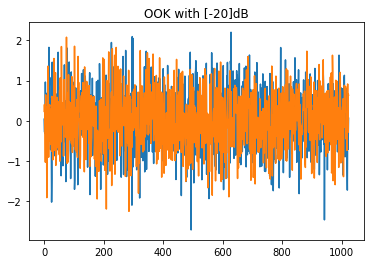

In [4]:
from matplotlib import pyplot as plt

# Plot IQ samples of the frame
plt.figure()
plt.title(f"{modulation_str} with {snr[idx]}dB")
plt.plot(data[idx])
plt.show()

In [5]:
# Closes the file
hdf5_file.close()

# 上述代码为数据集加载验证，下面为具体内容

# 安装与导入依赖

## 教学目标

让学生理解：

- 深度学习项目的基础依赖
- 时间序列可视化工具
- GPU 检查方法

## 建议代码


In [6]:
!pip install pyts -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

from scipy.signal import stft

from pyts.image import GramianAngularField
from pyts.image import MarkovTransitionField
from pyts.image import RecurrencePlot

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla P100-PCIE-16GB


# 加载 RadioML 数据集

## 教学目标

让学生理解：

- 数据集的基本组成
- IQ 信号的结构
- 调制识别本质上是分类任务

## 理论说明

RadioML 数据集通常包含：

X：IQ 信号 Y：调制标签 Z：信噪比（SNR）

其中：

I（In-phase）：同相分量 Q（Quadrature）：正交分量

IQ 信号本质上是二维时间序列：

x(t) = I(t) + jQ(t)

其中：

- I(t) 表示实部
- Q(t) 表示虚部

## 建议代码


In [7]:
file_path = '/kaggle/input/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5' # 请根据实际路径修改

# 1. 加载数据集
f = h5py.File(file_path, 'r')

In [9]:
# 2. 查看数据集的 Key
print("数据集包含的 Keys:", list(f.keys()))

# X: 信号数据 (N, 1024, 2) -> 1024个采样点，2通道(I/Q)
# Y: 标签 (N, 24) -> One-hot 编码
# Z: 信噪比 (N, 1) -> 每个样本对应的 SNR
X = f['X']
Y = f['Y']
Z = f['Z']

print(f"信号数据形状 (X): {X.shape}")
print(f"标签数据形状 (Y): {Y.shape}")
print(f"信噪比数据形状 (Z): {Z.shape}")

# 定义调制解调名称列表（2018.01A 标准顺序）
mods = ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', 
        '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', 
        '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 
        'FM', 'GMSK', 'OQPSK']

数据集包含的 Keys: ['X', 'Y', 'Z']
信号数据形状 (X): (2555904, 1024, 2)
标签数据形状 (Y): (2555904, 24)
信噪比数据形状 (Z): (2555904, 1)


### 🔍 数据维度深度解析 (Data Dimensions Breakdown)

在无线电信号处理中，维度的排列直接决定了我们如何“理解”信号：

#### 1. 信号数据 (X): `(2555904, 1024, 2)`
* **2,555,904 (Samples)**: 样本总数。这证明 RadioML 2018.01A 是一个海量数据集，非常适合深层神经网络的训练。
* **1024 (Time Steps / Sequence Length)**: 每个样本包含 **1024 个连续采样点**。
    * *原理*：采样率决定了我们观察信号的精细程度。
* **2 (Channels - I/Q)**: **最核心的维度**。
    * **I (In-phase)**: 同相分量（实部）。
    * **Q (Quadrature)**: 正交分量（虚部）。
    * *物理意义*：无线电信号是复数。在数字处理中，我们通过 I/Q 两路数据来完整描述信号的**幅度**和**相位**。公式表示为：$s(t) = I(t) + jQ(t)$。

#### 2. 标签数据 (Y): `(2555904, 24)`
* **24 (Classes)**: 代表 **24 种调制方式**（如 BPSK, QPSK, 16QAM, 64QAM, FM, AM 等）。
* **One-hot Encoding**: 数据采用独热编码。例如，如果第 3 类是 QPSK，那么对应标签就是 `[0, 0, 1, 0, ...]`。
    * *注意*：在训练 BiLSTM 或 CNN 时，我们需要将其转化为类别索引（CrossEntropy 常用）。

#### 3. 信噪比数据 (Z): `(2555904, 1)`
* **SNR (Signal-to-Noise Ratio)**: 每个样本对应的信噪比（单位为 **dB**）。
* *科研价值*：频谱感知的难点在于**低信噪比**下的识别。
    * 我们在评估模型时，不能只看“总准确率”，必须绘制 **Accuracy vs. SNR** 曲线。你会发现，随着 Z 值的增大，识别率会显著提升。

---

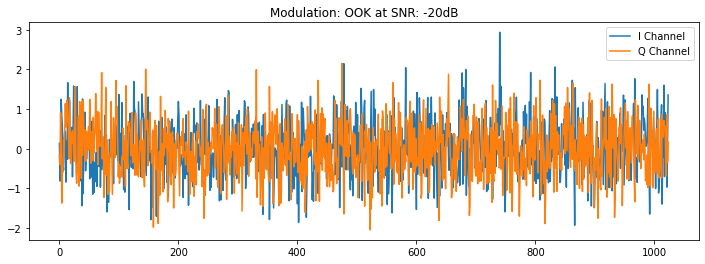

In [10]:
#单条数据可视化 (时域)
#目的：直观观察 I/Q 波形。
sample_idx = 1000  # 选一个样本
sample_x = X[sample_idx]
sample_y = Y[sample_idx]
sample_z = Z[sample_idx]

plt.figure(figsize=(12, 4))
plt.plot(sample_x[:, 0], label='I Channel')
plt.plot(sample_x[:, 1], label='Q Channel')
plt.title(f"Modulation: {mods[np.argmax(sample_y)]} at SNR: {sample_z[0]}dB")
plt.legend()
plt.show()

# STFT（短时傅里叶变换）

## 教学目标

让学生理解：

- 为什么需要时频分析
- STFT 如何同时保留时间与频率信息

## 理论说明

短时傅里叶变换：

$$STFT(x(t)) = \int x(\tau) w(\tau - t)e^{-j\omega\tau} d\tau$$

其中：

- w(t)：滑动窗口函数
- 不同时间窗口做傅里叶变换

输出结果：

- 横轴：时间
- 纵轴：频率
- 颜色：能量强度

## 建议代码

```python


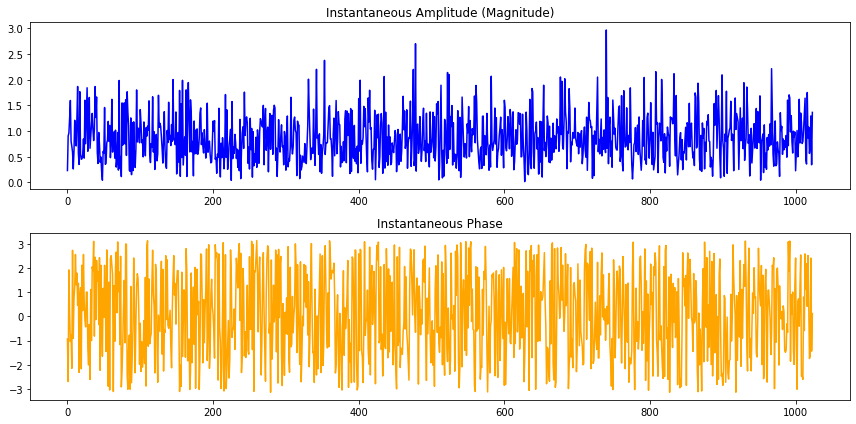

'\n【原理说明】\n无线电信号 s(t) = I(t) + jQ(t) 可以表示为极坐标形式：s(t) = A(t) * exp(jθ(t))\n1. 幅度 (Magnitude): A(t) = sqrt(I² + Q²) —— 反映信号能量变化。\n2. 相位 (Phase): θ(t) = arctan(Q/I) —— 反映信号的相位调制信息。\n'

In [11]:
# 提取单条数据的 I/Q 通道
I = sample_x[:, 0]
Q = sample_x[:, 1]
complex_signal = I + 1j * Q

# 计算瞬时幅度和瞬时相位
amplitude = np.abs(complex_signal)
phase = np.angle(complex_signal)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(amplitude, color='blue')
plt.title("Instantaneous Amplitude (Magnitude)")
plt.subplot(2, 1, 2)
plt.plot(phase, color='orange')
plt.title("Instantaneous Phase")
plt.tight_layout()
plt.show()

"""
【原理说明】
无线电信号 s(t) = I(t) + jQ(t) 可以表示为极坐标形式：s(t) = A(t) * exp(jθ(t))
1. 幅度 (Magnitude): A(t) = sqrt(I² + Q²) —— 反映信号能量变化。
2. 相位 (Phase): θ(t) = arctan(Q/I) —— 反映信号的相位调制信息。
"""

/opt/conda/lib/python3.7/site-packages/scipy/signal/spectral.py:1812: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '


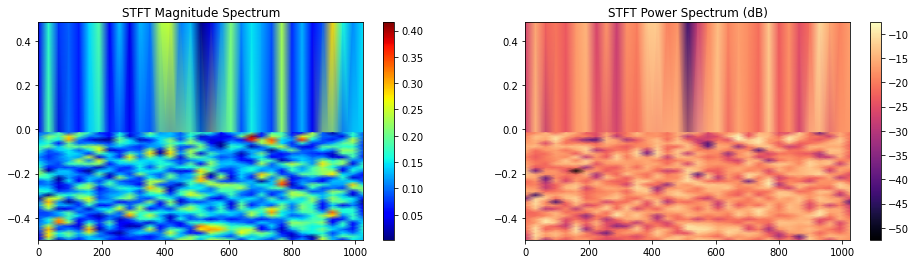

In [12]:
from scipy import signal

# 构造复数信号 (I + jQ)
complex_signal = sample_x[:, 0] + 1j * sample_x[:, 1]

# 计算 STFT
# nperseg: 窗口长度，影响频率分辨率和时间分辨率的平衡
f, t, Zxx = signal.stft(complex_signal, fs=1.0, nperseg=64)

# 提取幅度谱和功率谱
magnitude = np.abs(Zxx)
power = np.abs(Zxx)**2
log_power = 10 * np.log10(power + 1e-10) # 转换为dB，避免log(0)

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
im1 = ax1.pcolormesh(t, f, magnitude, shading='gouraud', cmap='jet')
ax1.set_title("STFT Magnitude Spectrum")
plt.colorbar(im1, ax=ax1)

im2 = ax2.pcolormesh(t, f, log_power, shading='gouraud', cmap='magma')
ax2.set_title("STFT Power Spectrum (dB)")
plt.colorbar(im2, ax=ax2)
plt.show()

# 📐 Gramian Angular Field (GAF) 深度解析

## 1. 核心教学目标
- **空间变换思想**：理解如何利用极坐标系将 1D 信号映射至 2D 空间而不损失信息。
- **几何与三角关系**：掌握 $cos(\phi_i \pm \phi_j)$ 在捕捉信号相位关系中的作用。
- **双模态互补性**：理解 Summation (和) 与 Difference (差) 两种场在特征提取上的差异。

## 2. 理论说明与几何推导

### A. 预处理：归一化与极坐标映射
为了将信号 $X = \{x_1, x_2, \dots, x_n\}$ 转化为角度，我们首先需要将其缩放到 $[-1, 1]$（或 $[0, 1]$）：
$$\tilde{x}_i = \frac{(x_i - \text{max}(X)) + (x_i - \text{min}(X))}{\text{max}(X) - \text{min}(X)}$$
然后，我们将每个值映射为角度 $\phi$ 和半径 $r$：
- **相位角**：$\phi_i = \arccos(\tilde{x}_i), \quad \phi_i \in [0, \pi]$
- **半径**：$r_i = \frac{t_i}{N}$（其中 $t_i$ 是时间步，代表时间随半径增加而演进）



### B. GASF (和场) —— 全局相关性
GASF 通过计算两个时间点角度之**和**的余弦值来定义：
$$G_{i,j} = \cos(\phi_i + \phi_j) = \tilde{x}_i \cdot \tilde{x}_j - \sqrt{1-\tilde{x}_i^2}\sqrt{1-\tilde{x}_j^2}$$
- **物理意义**：它是对称矩阵，对角线反映了信号的自身能量，非对角线反映了时间点间的非线性相关。它能较好地保持信号的**整体包络结构**。

### C. GADF (差场) —— 局部敏感性
GADF 通过计算两个时间点角度之**差**的正弦值来定义：
$$G_{i,j} = \sin(\phi_i - \phi_j) = \sqrt{1-\tilde{x}_i^2} \cdot \tilde{x}_j - \tilde{x}_i \cdot \sqrt{1-\tilde{x}_j^2}$$
- **物理意义**：它捕捉的是信号的**变化率**（类似于求导）。相比 GASF，GADF 对信号的波动、跳变和噪声更敏感，能更清晰地勾勒出无线电信号（如 PSK 的相位突变）的边缘。

---

## 建议代码

```python


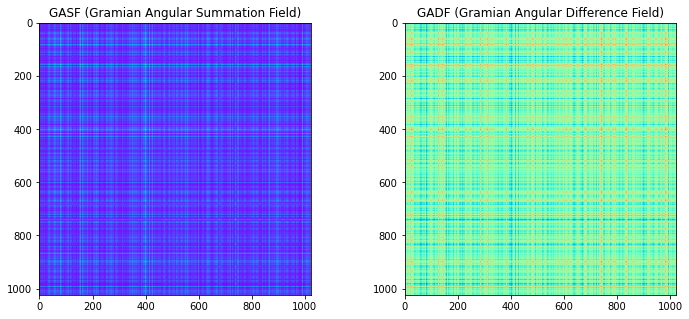

'\n【原理说明】\n1. 归一化：将序列缩放到 [-1, 1]。\n2. 极坐标转换：$\\phi = \x07rccos(x_i)$。\n3. 变换：\n   - GASF 公式：$G_{ij} = \\cos(\\phi_i + \\phi_j) = x_i \\cdot x_j - \\sqrt{1-x_i^2}\\sqrt{1-x_j^2}$\n   - GADF 公式：$G_{ij} = \\sin(\\phi_i - \\phi_j) = \\sqrt{1-x_i^2} \\cdot x_j - x_i \\cdot \\sqrt{1-x_j^2}$\n这种方法在保留时间顺序的同时，通过角度的和差捕获了非线性相关性。\n'

In [13]:
from pyts.image import GramianAngularField

# 数据预处理：pyts 需要 (n_samples, n_timestamps) 格式
data_reshaped = I.reshape(1, -1) 

gasf = GramianAngularField(method='summation')
gadf = GramianAngularField(method='difference')

img_gasf = gasf.fit_transform(data_reshaped)
img_gadf = gadf.fit_transform(data_reshaped)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_gasf[0], cmap='rainbow')
ax[0].set_title("GASF (Gramian Angular Summation Field)")
ax[1].imshow(img_gadf[0], cmap='rainbow')
ax[1].set_title("GADF (Gramian Angular Difference Field)")
plt.show()

"""
【原理说明】
1. 归一化：将序列缩放到 [-1, 1]。
2. 极坐标转换：$\phi = \arccos(x_i)$。
3. 变换：
   - GASF 公式：$G_{ij} = \cos(\phi_i + \phi_j) = x_i \cdot x_j - \sqrt{1-x_i^2}\sqrt{1-x_j^2}$
   - GADF 公式：$G_{ij} = \sin(\phi_i - \phi_j) = \sqrt{1-x_i^2} \cdot x_j - x_i \cdot \sqrt{1-x_j^2}$
这种方法在保留时间顺序的同时，通过角度的和差捕获了非线性相关性。
"""

# 📊 MTF 与 MDF：马尔可夫动态场分析

## 1. 核心教学目标
- **多维度状态捕捉**：理解从“绝对位置”（幅度）与“相对变化”（差分）两个角度刻画信号。
- **动态特性提取**：掌握如何通过差分算子（Differential Operator）提升对相位/频率突变的感知力。
- **双模态对比逻辑**：学会通过分析两张图的纹理差异来识别不同的调制协议。

## 2. 理论说明与公式推导

### A. 马尔可夫转移场 (MTF) —— 关注“位置”
MTF 描述的是原始 IQ 信号在幅度空间中的跳变。
1. **状态划分**：将信号 $X$ 划分为 $Q$ 个分箱。
2. **转移概率**：计算一阶转移概率矩阵 $W_{Q \times Q}$。
3. **映射**：$M_{ij} = W_{q_i, q_j}$。
> **物理意义**：MTF 能够直观展示信号在不同幅度电平间的切换节奏。对于 **ASK（幅移键控）** 信号，其 MTF 会有极其规整的块状结构。



### B. 马尔可夫差分场 (MDF) —— 关注“速度”
MDF 是先对信号进行**一阶差分**，再进行马尔可夫场变换。
1. **差分运算**：$\Delta x_t = x_t - x_{t-1}$。
2. **状态划分与映射**：对序列 $\Delta X$ 执行与 MTF 相同的变换流程。
> **物理意义**：MDF 刻画的是信号的**瞬时变化率**。对于 **PSK（相移键控）** 或 **FSK（频移键控）**，虽然信号幅度（MTF）可能保持恒定，但在相位翻转或频率切换点，$\Delta x_t$ 会产生巨大跳变，MDF 能够捕捉到这些微观的动态“指纹”。

## 建议代码



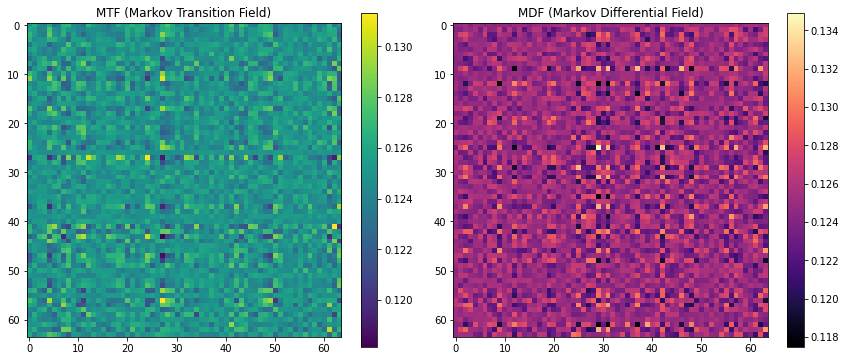

'\n【原理说明】MDF\n公式：$\\Delta x_t = x_t - x_{t-1}$\nMDF 实际上是先对信号求导（差分），再进行 MTF 变换。\n- MTF 关注的是“位置”（幅度在哪里）。\n- MDF 关注的是“速度”（幅度变化得快慢）。\n'

In [14]:
from pyts.image import MarkovTransitionField
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备数据
data_reshaped = I.reshape(1, -1) 
# 计算一阶差分（Differential），捕捉信号的动态斜率
I_diff = np.diff(I, prepend=I[0]).reshape(1, -1)

# 2. 实例化变换器
# 提示学生：image_size 决定了最后图像的分辨率，n_bins 决定了状态划分的细腻程度
mtf_transformer = MarkovTransitionField(image_size=64, n_bins=8)

# 3. 得到变换结果
img_mtf = mtf_transformer.fit_transform(data_reshaped)
img_mdf = mtf_transformer.fit_transform(I_diff)

# 4. 并排可视化对比
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# MTF 展示
im0 = ax[0].imshow(img_mtf[0], cmap='viridis')
ax[0].set_title("MTF (Markov Transition Field)")
fig.colorbar(im0, ax=ax[0])

# MDF 展示
im1 = ax[1].imshow(img_mdf[0], cmap='magma')
ax[1].set_title("MDF (Markov Differential Field)")
fig.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

"""
【原理说明】MTF
1. 将信号的幅度范围划分为 Q 个分箱（Bins）。
2. 考察信号在不同时间点落在哪个分箱内（即状态）。
3. $M_{ij}$ 表示时间点 $i$ 的状态转移到时间点 $j$ 的状态的概率。
它能捕捉信号的动态演变过程。
"""

"""
【原理说明】MDF
公式：$\Delta x_t = x_t - x_{t-1}$
MDF 实际上是先对信号求导（差分），再进行 MTF 变换。
- MTF 关注的是“位置”（幅度在哪里）。
- MDF 关注的是“速度”（幅度变化得快慢）。
"""

# RP (Recurrence Plot) 和 RPM (Recurrence Plot Matrix)

## 教学目标

让学生理解：

- 动态系统重复模式
- 时序结构规律

## 理论说明

### 1. 递归图 (Recurrence Plot, RP)

**原理**：RP 揭示了信号在相空间中的轨迹是否、以及何时回到了之前经过的状态。对于调制信号，如果信号是平稳的或周期性的，RP 图会呈现出平行的对角线或规律的方块。
**物理意义**：它能捕捉到信号的非线性特征。

**LaTeX 公式**：
$$R_{i,j} = \Theta(\epsilon - ||\vec{s}_i - \vec{s}_j||), \quad i,j \in \{1, \dots, N\}$$

* $\vec{s}_i$：信号在 $i$ 时刻的向量。
* $||\cdot||$：范数（通常采用欧几里得范数），衡量两个状态间的距离。
* $\epsilon$：预设的阈值（Tolerance）。
* $\Theta$：海维赛德阶跃函数（Heaviside function），如果距离小于阈值，结果为 1（黑点），否则为 0（白点）。
---

### 2. 递归概率矩阵 (Recurrence Plot Matrix, RPM)

**原理**：RPM 是 RP 的升级版或连续版。传统的 RP 是二值的（0 或 1），而 RPM（有时也指距离矩阵 Recurrence Matrix）通常保留了状态之间的**连续距离信息**，或者通过核函数将距离映射到 $[0, 1]$ 区间。
**物理意义**：RPM 提供了比二值化 RP 更丰富的层次感，非常适合 CNN 提取细微的信号波动特征。

**LaTeX 公式（常用高斯核版本）**：
$$RPM_{i,j} = \exp\left(-\frac{||\vec{s}_i - \vec{s}_j||^2}{2\sigma^2}\right)$$

* $\sigma$：控制距离衰减权重的超参数。
* 这种表达方式将信号转换为热力图，距离越近的点，数值越接近 1。

---

## 建议代码


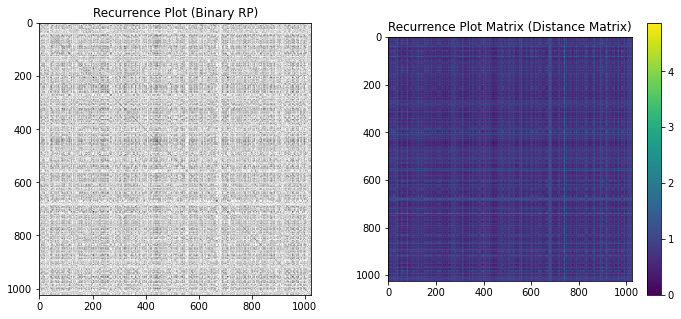

'\n【原理说明】\n公式：$R_{i,j} = \\Theta(\\epsilon - \\| \x0bec{x}_i - \x0bec{x}_j \\|)$\n- 其中 $\\Theta$ 是阶跃函数，$\\epsilon$ 是阈值。\n- 如果时间点 $i$ 和 $j$ 的状态足够接近（距离小于阈值），则图中对应点为黑色。\n- 周期信号在 RP 图中会出现等间距的对角线。\n- RPM (Recurrence Plot Matrix) 通常指未经过阈值二值化的原始距离矩阵。\n'

In [15]:
from pyts.image import RecurrencePlot
import matplotlib.pyplot as plt

# 提取单路信号 (例如 I 路) 并确保是 2D 形状 [1, 1024]
data_1d = X[sample_idx][:, 0].reshape(1, -1) 

# 1. 生成二值化 RP (Recurrence Plot)
# 设定阈值为所有距离点的下分位数 20%
rp_binary = RecurrencePlot(threshold='point', percentage=20)
img_rp = rp_binary.transform(data_1d)

# 2. 生成 RPM (Recurrence Plot Matrix / Distance Matrix)
# threshold=None 时，pyts 会返回原始的欧几里得距离矩阵
rp_dist = RecurrencePlot(threshold=None)
img_rpm = rp_dist.transform(data_1d)

# 可视化对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(img_rp[0], cmap='binary')
ax1.set_title("Recurrence Plot (Binary RP)")

# RPM 通常用热力图显示，距离越小越亮（或越暗，取决于 cmap）
im2 = ax2.imshow(img_rpm[0], cmap='viridis')
ax2.set_title("Recurrence Plot Matrix (Distance Matrix)")
plt.colorbar(im2, ax=ax2)
plt.show()

"""
【原理说明】
公式：$R_{i,j} = \Theta(\epsilon - \| \vec{x}_i - \vec{x}_j \|)$
- 其中 $\Theta$ 是阶跃函数，$\epsilon$ 是阈值。
- 如果时间点 $i$ 和 $j$ 的状态足够接近（距离小于阈值），则图中对应点为黑色。
- 周期信号在 RP 图中会出现等间距的对角线。
- RPM (Recurrence Plot Matrix) 通常指未经过阈值二值化的原始距离矩阵。
"""

# 🧠 BiLSTM 神经网络结构深度解析 (Architecture Analysis)

为了帮助大家理解这段 PyTorch 代码，我们将从数据流（Data Flow）的角度拆解模型：

## 1. 数据的“生命周期” (Data Flow)
模型的 `forward` 函数定义了数据进入网络后的变换逻辑：
* **输入 `x`**: 形状为 `(Batch, 1024, 2)`。
    * `1024`: 采样点的时间序列长度。
    * `2`: 每个点的 I/Q 分量特征。
* **LSTM 变换**: 经过 `self.lstm` 后，输出形状变为 `(Batch, 1024, 128)`。
    * 为什么是 `128`？因为 `hidden_size=64` 且设置了 `bidirectional=True`（$64 \times 2 = 128$）。
* **特征提取**: `out[:, -1, :]` 代表只取 **最后一个时间步** 的隐藏状态。这被认为包含了整个 1024 长度序列的总结特征。
* **分类输出**: 经过全连接层 `self.fc`，最终输出 `(Batch, 24)`，对应 24 种调制的置信度。

## 2. 关键组件解析 (Component Roles)
* **`__init__` 函数 (构造函数)**: 相当于“购买零件”。
    * `nn.LSTM`: 负责处理时间序列，提取时域特征。
    * `nn.Sequential`: 这是一个容器，按顺序包装了线性层（Linear）、激活函数（ReLU）和防止过拟合的丢弃层（Dropout）。
* **`forward` 函数 (前向传播)**: 相当于“组装零件”。它规定了零件之间是如何串联的。



## 3. 为什么选择 BiLSTM 处理无线电信号？
* **时序依赖**: 信号的当前相位往往与前后的采样值都存在强相关性。
* **双向感官**: 
    * **前向 (Forward)**: 捕捉信号的频率演变。
    * **后向 (Backward)**: 捕捉信号在时域上的逆向关联。
    * 两者拼接后，模型能比单向 LSTM 更全面地识别出复杂的星座图跳变模式。

# 基于 RadioML 2018.01A 的频谱感知完整教学流程
## —— H0/H1 二分类 · 三阶段实验设计 · BiLSTM

> **核心问题**：给定一段 IQ 采样序列，判断当前信道是否被主用户占用。
>
> **数据来源**：DeepSig RadioML 2018.01A（Kaggle）

---

## 📌 一、什么是频谱感知？它和调制识别有何本质区别？

| | 调制识别（AMC） | 狭义频谱感知（SS） |
|--|--|--|
| **问题** | 信号是哪种调制方式？ | 信道上有没有信号？ |
| **输出** | 24类标签 | H0（空闲）/ H1（占用）|
| **本质** | 多分类 | 二分类 / 假设检验 |
| **关键指标** | Accuracy, F1 | Pd, Pfa, ROC, AUC |

### 数学模型

接收信号 $y(n)$ 满足二元假设检验：

$$y(n) = \begin{cases} w(n) & H_0\text{：主用户不在，信道空闲} \\ s(n) + w(n) & H_1\text{：主用户存在，信道被占用} \end{cases}$$

其中 $s(n)$ 为主用户调制信号（BPSK/QAM/FM等任意一种），$w(n)$ 为加性高斯白噪声（AWGN）。

**频谱感知的目标**：设计检测器 $f(\cdot)$，使得：
- **检测概率** $P_d = P(\hat{H}=H_1 \mid H_1) \rightarrow$ 越高越好（别漏掉主用户）
- **虚警概率** $P_{fa} = P(\hat{H}=H_1 \mid H_0) \rightarrow$ 越低越好（别误报占用）

---

## 📌 二、为什么 RadioML 能做频谱感知？24种调制方式怎么处理？

RadioML 里有 24 种调制方式，但频谱感知**不关心是哪种调制**，只关心「有没有信号」。

```
BPSK @ any SNR  ─┐
QPSK @ any SNR  ─┤
16QAM @ any SNR ─┤─→  全部打标签 H1（主用户存在）
FM @ any SNR    ─┤
...（14种）      ─┘

纯 AWGN 噪声    ──→  打标签 H0（信道空闲）
SNR=-20dB 样本  ──→  打标签 H0（信号被噪声完全淹没，工程上等价空闲）
```

模型学到的不是「这是BPSK」，而是「这段序列有结构/规律，不像纯随机噪声」。

---

## 📌 三、实验设计总览（三阶段）

```
┌──────────┬─────────────────┬──────────────────┬───────────────────────────┐
│          │  调制方式        │  SNR → 标签       │  目的                     │
├──────────┼─────────────────┼──────────────────┼───────────────────────────┤
│ 训练+验证 │ 已知14种        │ -20dB    → H0    │ 建立基线                   │
│          │                 │ -10~+10dB → H1   │                           │
│          │                 │ + 纯AWGN  → H0   │                           │
├──────────┼─────────────────┼──────────────────┼───────────────────────────┤
│ 测试集1  │ 已知14种（相同） │ -20dB    → H0    │ SNR泛化：训练未覆盖的信噪比  │
│          │                 │ 其余SNR   → H1   │ [-18~-12dB, +12~+30dB]   │
│          │                 │ + 纯AWGN  → H0   │                           │
├──────────┼─────────────────┼──────────────────┼───────────────────────────┤
│ 测试集2  │ 未知10种（未见） │ -20dB    → H0    │ 调制泛化：真正的盲检测能力   │
│          │                 │ 其余SNR   → H1   │                           │
│          │                 │ + 纯AWGN  → H0   │                           │
└──────────┴─────────────────┴──────────────────┴───────────────────────────┘
```

---

## 🗺️ Notebook 结构

1. 环境安装与导入
2. 数据集加载与整体探索
3. 数据集构建（H0/H1标签 + 三阶段划分）
4. 数据预处理
5. PyTorch Dataset & DataLoader
6. BiLSTM 模型搭建
7. 训练与验证
8. 三阶段评估（基线 / SNR泛化 / 调制泛化）
9. 全面可视化

---
## Cell 1 — 安装依赖

In [1]:
# ============================================================
# Cell 1: 安装依赖
# ============================================================
!pip install h5py scikit-learn matplotlib seaborn torch -q
print('✅ 安装完成')

✅ 安装完成


---
## Cell 2 — 统一导入

In [2]:
# ============================================================
# Cell 2: 统一导入所有依赖
# ============================================================
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ 使用设备: {DEVICE}')

✅ 使用设备: cuda


---
## Cell 3 — 加载 RadioML 2018.01A & 整体探索

### RadioML 2018.01A 数据集结构

| 字段 | Shape | 说明 |
|------|-------|------|
| `X` | `(N, 2, 1024)` | IQ 信号，第0行=I分量，第1行=Q分量 |
| `Y` | `(N, 24)` | One-hot 调制类型标签 |
| `Z` | `(N, 1)` | SNR 值，范围 -20dB ~ +30dB，步长 2dB |

**IQ 信号物理含义**：
$$s(t) = I(t)\cos(2\pi f_c t) - Q(t)\sin(2\pi f_c t)$$
其中 $I(t)$ 为同相分量，$Q(t)$ 为正交分量，两者共同描述信号的幅度和相位。

---
### 分层均匀抽样（只读 Y 和 Z，不读 X）

### 为什么这样做？

RadioML 2018.01A 完整 X 数据约 **20 GB**，Kaggle 内存上限约 16 GB，
一次性 `f['X'][:]` 必然 OOM（Out of Memory）。

### 解决思路

```
传统（慢且OOM）：         本方案（快且省内存）：
X = f['X'][:]            只读 Y 和 Z（几十MB）
                          ↓
全部加载进内存            建立 selected_indices 数组
                          ↓
内存爆炸 💥              Dataset.__getitem__ 时
                          按需从HDF5读单条
                          ↓
                          内存始终可控 ✅
```

### HDF5 顺序读取 vs 随机读取

HDF5 文件在磁盘上是按行顺序存储的，**乱序索引读取极慢**（每次跳盘），
所以抽样后必须 `sorted(selected_indices)` 再读，速度提升 10~100x。

In [3]:
# ============================================================
# Cell 3: 分层均匀抽样
#
# 只读 Y（标签）和 Z（SNR），建立抽样索引。
# X 数据不在这里读取！
#
# 抽样策略：
#   每种调制方式：10,000 条
#   每种调制内按 SNR 均匀分配：10000 / 26档 ≈ 384条/档
#   总计：24 × 10000 = 240,000 条
# ============================================================

HDF5_PATH = '/kaggle/input/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5'

# ── 步骤1：只读 Y 和 Z（内存友好，几十MB）────────────────────
print('📖 读取 Y 和 Z...')
with h5py.File(HDF5_PATH, 'r') as f:
    Y_raw = f['Y'][:]   # (N, 24)  One-hot，几十MB
    Z_raw = f['Z'][:]   # (N, 1)   SNR，几MB

y_mod_full = np.argmax(Y_raw, axis=1)   # (N,) 调制类型索引
snr_full   = Z_raw.flatten()             # (N,) SNR值
del Y_raw, Z_raw   # 立即释放原始one-hot数组

MOD_CLASSES = [
    'OOK','4ASK','8ASK','BPSK','QPSK','8PSK',
    '16PSK','32PSK','16APSK','32APSK','64APSK',
    '128APSK','16QAM','32QAM','64QAM','128QAM',
    '256QAM','AM-SSB-WC','AM-SSB-SC','AM-DSB-WC',
    'AM-DSB-SC','FM','GMSK','OQPSK'
]
NUM_MOD  = len(MOD_CLASSES)
ALL_SNRS = sorted(np.unique(snr_full).tolist())   # [-20,-18,...,+30]
ALL_MODS = sorted(np.unique(y_mod_full).tolist())

print(f'  总样本数: {len(y_mod_full):,}')
print(f'  调制种类: {NUM_MOD}  |  SNR档位: {len(ALL_SNRS)}')
print(f'  SNR范围: {ALL_SNRS[0]} ~ {ALL_SNRS[-1]} dB')

# ── 步骤2：分层均匀抽样，只建索引 ───────────────────────────
SAMPLES_PER_MOD = 10_000                            # 每种调制总条数
SAMPLES_PER_SNR = SAMPLES_PER_MOD // len(ALL_SNRS) # 每档SNR的条数（约384）

print(f'\n🎯 抽样计划：')
print(f'  每种调制: {SAMPLES_PER_MOD:,} 条')
print(f'  每档SNR : {SAMPLES_PER_SNR} 条')
print(f'  总计    : {NUM_MOD * SAMPLES_PER_MOD:,} 条')
print('\n计算索引中...')

selected_indices = []   # 只存整数索引，约 240000×4字节 ≈ 1MB，极省内存

for m in ALL_MODS:
    for s in ALL_SNRS:
        # 找到 调制=m 且 SNR=s 的所有行号
        pool = np.where((y_mod_full == m) & (snr_full == s))[0]
        n_take = min(SAMPLES_PER_SNR, len(pool))
        chosen = np.random.choice(pool, n_take, replace=False)
        selected_indices.extend(chosen.tolist())

# 排序！HDF5顺序读取比随机跳读快 10~100 倍
selected_indices = sorted(selected_indices)
selected_indices = np.array(selected_indices, dtype=np.int32)

# 对应的调制类型和SNR（从全量数组直接索引，无需读X）
y_mod_sel = y_mod_full[selected_indices]   # (240000,)
snr_sel   = snr_full[selected_indices]     # (240000,)

del y_mod_full, snr_full   # 释放全量数组

# ── 步骤3：验证抽样均匀性 ────────────────────────────────────
print(f'\n✅ 抽样完成！总索引数: {len(selected_indices):,}')
print(f'\n每种调制的样本数（应均为 {SAMPLES_PER_MOD}）：')
for m_idx in ALL_MODS:
    cnt = (y_mod_sel == m_idx).sum()
    bar = '█' * (cnt // 200)
    print(f'  [{m_idx:2d}] {MOD_CLASSES[m_idx]:<12} {cnt:5,} {bar}')

print(f'\n每档SNR的样本数（应均匀）：')
for s in ALL_SNRS:
    cnt = (snr_sel == s).sum()
    print(f'  SNR={s:4.0f}dB  {cnt:,}')

📖 读取 Y 和 Z...
  总样本数: 2,555,904
  调制种类: 24  |  SNR档位: 26
  SNR范围: -20 ~ 30 dB

🎯 抽样计划：
  每种调制: 10,000 条
  每档SNR : 384 条
  总计    : 240,000 条

计算索引中...

✅ 抽样完成！总索引数: 239,616

每种调制的样本数（应均为 10000）：
  [ 0] OOK          9,984 █████████████████████████████████████████████████
  [ 1] 4ASK         9,984 █████████████████████████████████████████████████
  [ 2] 8ASK         9,984 █████████████████████████████████████████████████
  [ 3] BPSK         9,984 █████████████████████████████████████████████████
  [ 4] QPSK         9,984 █████████████████████████████████████████████████
  [ 5] 8PSK         9,984 █████████████████████████████████████████████████
  [ 6] 16PSK        9,984 █████████████████████████████████████████████████
  [ 7] 32PSK        9,984 █████████████████████████████████████████████████
  [ 8] 16APSK       9,984 █████████████████████████████████████████████████
  [ 9] 32APSK       9,984 █████████████████████████████████████████████████
  [10] 64APSK       9,984 ████████████████████

---
## Cell 4 — 实验设计：调制方式划分 & SNR规划

In [12]:
# ============================================================
# Cell 4: 定义已知/未知调制，以及各数据集的SNR区间
# ============================================================

# ── 调制方式划分 ─────────────────────────────────────────────
KNOWN_MODS = [
    'BPSK','QPSK','8PSK','16PSK',          # 相位调制族
    'OOK','4ASK','8ASK',                    # 幅度调制族
    '16QAM','32QAM','64QAM',                # QAM族（低阶）
    'AM-DSB-SC','AM-SSB-SC',               # 模拟调制（抑制载波）
    'GMSK','OQPSK'                          # 扩频/特殊
]
UNKNOWN_MODS = [
    '32PSK','16APSK','32APSK','64APSK','128APSK',   # 高阶相位/幅度相位
    '128QAM','256QAM',                               # 高阶QAM
    'AM-DSB-WC','AM-SSB-WC',                         # 带载波模拟调制
    'FM'                                              # 频率调制
]

known_idx   = [MOD_CLASSES.index(m) for m in KNOWN_MODS]
unknown_idx = [MOD_CLASSES.index(m) for m in UNKNOWN_MODS]
assert len(known_idx) + len(unknown_idx) == NUM_MOD

# ── SNR 区间规划 ──────────────────────────────────────────────
#
# 训练集 H1：中间区间 [-10, +10] dB（11档）
#   模型见过这个SNR范围，但不含极端情况
#
# 测试集1 H1：训练未覆盖的SNR
#   低端：[-18, -12] dB（低SNR外推）
#   高端：[+12, +30] dB（高SNR外推）
#   目的：测试SNR泛化能力
#
# 测试集2 H1：全SNR范围（排除-20dB）
#   目的：测试调制泛化能力（盲检测）
#
# H0：SNR=-20dB 的样本（信号被噪声淹没，工程上≈空闲）
#     + 纯AWGN（增强H0多样性）

H0_SNR        = -20
TRAIN_H1_SNRS = [s for s in ALL_SNRS if -15 <= s <= 15]
TEST1_H1_SNRS = [s for s in ALL_SNRS if (s < -15 or s > 15) and s != H0_SNR]
TEST2_H1_SNRS = [s for s in ALL_SNRS if s != H0_SNR]

print('='*60)
print('📋 实验设计确认')
print('='*60)
print(f'已知调制（{len(KNOWN_MODS)}种）: {KNOWN_MODS}')
print(f'未知调制（{len(UNKNOWN_MODS)}种）: {UNKNOWN_MODS}')
print(f'训练H1 SNR ({len(TRAIN_H1_SNRS)}档): {TRAIN_H1_SNRS}')
print(f'测试1 H1 SNR({len(TEST1_H1_SNRS)}档): {TEST1_H1_SNRS}')
print(f'测试2 H1 SNR({len(TEST2_H1_SNRS)}档): {TEST2_H1_SNRS}')
print(f'H0 SNR: {H0_SNR} dB')

📋 实验设计确认
已知调制（14种）: ['BPSK', 'QPSK', '8PSK', '16PSK', 'OOK', '4ASK', '8ASK', '16QAM', '32QAM', '64QAM', 'AM-DSB-SC', 'AM-SSB-SC', 'GMSK', 'OQPSK']
未知调制（10种）: ['32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '128QAM', '256QAM', 'AM-DSB-WC', 'AM-SSB-WC', 'FM']
训练H1 SNR (15档): [-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14]
测试1 H1 SNR(10档): [-18, -16, 16, 18, 20, 22, 24, 26, 28, 30]
测试2 H1 SNR(25档): [-18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
H0 SNR: -20 dB


---
## Cell 5 — 实验设计：调制方式划分

### 为什么要切割调制方式？

频谱感知的真正价值在于「盲检测」——不管主用户用什么调制方式，都能检测到。
通过让模型在训练时只见过部分调制方式，测试时遇到未知调制，可以验证模型是否真正
学到了「信号 vs 噪声」的本质特征，而不是在记忆特定调制的波形。

### H0 的构造逻辑（SNR-wall 理论依据）

$$\text{SNR-wall}:\quad \text{当 SNR} \leq \text{SNR}_{wall}\text{ 时，任何检测器均无法可靠区分 H0/H1}$$

本实验将 SNR = -20dB 的样本标记为 H0，依据：
- 信号功率 : 噪声功率 = $10^{-20/10}$ = 1:100
- 信号完全被噪声淹没，工程上等价于信道空闲
- 同时生成纯 AWGN 作为 H0，两者混合，增强负样本多样性

### AWGN 生成公式

对每个 SNR 档位 $\gamma$（dB），生成功率匹配的复高斯白噪声：

$$\sigma_n = \frac{1}{\sqrt{10^{\gamma/10}}} \quad \Rightarrow \quad w(t) \sim \mathcal{CN}(0, \sigma_n^2)$$

即 $I_{noise}, Q_{noise} \sim \mathcal{N}(0, \sigma_n^2/2)$，使噪声功率与信号功率之比恰好等于指定 SNR。

---
### 构建数据集索引（核心 Cell）

### 关键设计：全程不读 X，只存行号

```python
# 传统方式（OOM）：
X_train = X[mask]          # 直接切片，几个GB进内存

# 本方案（内存安全）：
train_indices = indices[mask]   # 只存行号，几十KB
# 真正读取发生在 DataLoader 的 __getitem__ 里，每次只读一条
```

### H0 的两种来源

```
来源1：从RadioML取 SNR=-20dB 的样本
       → 真实采集信号，但功率极低（信号/噪声=1:100），工程上≈噪声

来源2：纯AWGN（程序生成）
       → 理想高斯白噪声，增强H0多样性，避免模型过拟合到某种特定噪声
```

AWGN 生成公式（存到临时 numpy 数组，不走HDF5）：
$$\sigma = \frac{1}{\sqrt{2 \cdot 10^{\gamma/10}}}, \quad I_{noise},Q_{noise} \sim \mathcal{N}(0, \sigma^2)$$

In [13]:
# ============================================================
# Cell 5: 构建三阶段数据集索引（修正版）
# ============================================================

def get_mask(y_arr, snr_arr, mod_indices, snr_list):
    return np.isin(y_arr, mod_indices) & np.isin(snr_arr, snr_list)

def generate_awgn(n_samples, snr_db_list, n_points=1024):
    """
    生成纯AWGN负样本。
    σ = 1/√(2×10^(γ/10))，I,Q ~ N(0,σ²)
    shape: (n_samples, 1024, 2)
    """
    per_snr = max(1, n_samples // len(snr_db_list))
    chunks  = []
    for snr_db in snr_db_list:
        snr_lin = 10 ** (snr_db / 10.0)
        sigma   = 1.0 / np.sqrt(2.0 * snr_lin)
        noise   = (np.random.randn(per_snr, n_points, 2) * sigma).astype(np.float32)
        chunks.append(noise)
    arr = np.concatenate(chunks, axis=0)
    # 补足或截断到精确数量
    while len(arr) < n_samples:
        arr = np.concatenate([arr, arr], axis=0)
    return arr[:n_samples]

# ================================================================
# 训练+验证集
# ================================================================
print('📦 构建训练/验证集...')

# H1：14种已知调制，SNR∈[-10,+10]dB
mask_tv_h1 = get_mask(y_mod_sel, snr_sel, known_idx, TRAIN_H1_SNRS)
tv_h1_pos  = np.where(mask_tv_h1)[0]
n_h1_tv    = len(tv_h1_pos)

# H0来源1：已知调制，SNR=-20dB（数量有限，全部用上）
mask_tv_h0d = get_mask(y_mod_sel, snr_sel, known_idx, [H0_SNR])
tv_h0d_pos  = np.where(mask_tv_h0d)[0]
n_h0d_tv    = len(tv_h0d_pos)

# H0来源2：纯AWGN，补足到与H1等量
# 目标：H0总量 = H1总量（1:1均衡）
n_awgn_tv_need = n_h1_tv - n_h0d_tv   # AWGN补足剩余
n_awgn_tv_need = max(n_awgn_tv_need, n_h0d_tv)  # 至少和H0_data等量
awgn_tv = generate_awgn(n_awgn_tv_need, TRAIN_H1_SNRS)

# 最终H0总量
n_h0_tv = n_h0d_tv + len(awgn_tv)
# 让H1和H0总量对齐（取较小值）
n_final_tv = min(n_h1_tv, n_h0_tv)
tv_h1_pos  = tv_h1_pos[np.random.choice(n_h1_tv, n_final_tv, replace=False)]

print(f'  H1={len(tv_h1_pos):,}  H0_data={n_h0d_tv:,}  H0_awgn={len(awgn_tv):,}')
print(f'  H0总量={n_h0_tv:,}  最终H1={n_final_tv:,}')

# 80/20 划分（按比例切分每个来源）
def split80(arr, is_numpy_arr=False):
    n = len(arr)
    n_tr = int(0.8 * n)
    if is_numpy_arr:
        return arr[:n_tr], arr[n_tr:]
    return arr[:n_tr], arr[n_tr:]

train_h1_pos,  val_h1_pos  = split80(tv_h1_pos)
train_h0d_pos, val_h0d_pos = split80(tv_h0d_pos)
train_awgn,    val_awgn    = split80(awgn_tv, is_numpy_arr=True)

print(f'\n  训练集: H1={len(train_h1_pos):,}  H0_data={len(train_h0d_pos):,}  H0_awgn={len(train_awgn):,}')
print(f'  验证集: H1={len(val_h1_pos):,}  H0_data={len(val_h0d_pos):,}  H0_awgn={len(val_awgn):,}')
print(f'  训练集总量≈{len(train_h1_pos)+len(train_h0d_pos)+len(train_awgn):,}')

# ================================================================
# 测试集1（已知调制，训练外SNR → SNR泛化）
# ================================================================
print('\n📦 构建测试集1（SNR泛化）...')

mask_t1_h1 = get_mask(y_mod_sel, snr_sel, known_idx, TEST1_H1_SNRS)
t1_h1_pos  = np.where(mask_t1_h1)[0]
n_t1_h1    = len(t1_h1_pos)

# 测试集1的H0：只用AWGN（数量与H1相等，1:1）
awgn_t1   = generate_awgn(n_t1_h1, TEST1_H1_SNRS)
snr_t1_h1 = snr_sel[t1_h1_pos]   # 保存SNR信息，用于画Pd-SNR曲线

print(f'  H1={n_t1_h1:,}  H0_awgn={len(awgn_t1):,}')
print(f'  测试集1总量≈{n_t1_h1 + len(awgn_t1):,}')

# ================================================================
# 测试集2（未知调制，全SNR → 调制泛化）
# ================================================================
print('\n📦 构建测试集2（调制泛化）...')

mask_t2_h1  = get_mask(y_mod_sel, snr_sel, unknown_idx, TEST2_H1_SNRS)
t2_h1_pos   = np.where(mask_t2_h1)[0]
n_t2_h1     = len(t2_h1_pos)

# H0来源1：未知调制，SNR=-20dB
mask_t2_h0d = get_mask(y_mod_sel, snr_sel, unknown_idx, [H0_SNR])
t2_h0d_pos  = np.where(mask_t2_h0d)[0]
n_h0d_t2    = len(t2_h0d_pos)

# H0来源2：AWGN补足到与H1等量
n_awgn_t2_need = n_t2_h1 - n_h0d_t2
n_awgn_t2_need = max(n_awgn_t2_need, n_h0d_t2)
awgn_t2 = generate_awgn(n_awgn_t2_need, TEST2_H1_SNRS)

n_h0_t2  = n_h0d_t2 + len(awgn_t2)
n_t2_h1_final = min(n_t2_h1, n_h0_t2)
t2_h1_pos = t2_h1_pos[np.random.choice(n_t2_h1, n_t2_h1_final, replace=False)]

# 保存细粒度信息（用于热力图）
snr_t2_h1 = snr_sel[t2_h1_pos]
mod_t2_h1 = y_mod_sel[t2_h1_pos]

print(f'  H1={len(t2_h1_pos):,}  H0_data={n_h0d_t2:,}  H0_awgn={len(awgn_t2):,}')
print(f'  测试集2总量≈{len(t2_h1_pos)+n_h0d_t2+len(awgn_t2):,}')

print('\n✅ 索引构建完成！')
print(f'\n📊 各数据集规模汇总：')
print(f'  训练集 : ~{len(train_h1_pos)+len(train_h0d_pos)+len(train_awgn):,} 条')
print(f'  验证集 : ~{len(val_h1_pos)+len(val_h0d_pos)+len(val_awgn):,} 条')
print(f'  测试集1: ~{n_t1_h1+len(awgn_t1):,} 条  （SNR泛化）')
print(f'  测试集2: ~{len(t2_h1_pos)+n_h0d_t2+len(awgn_t2):,} 条  （调制泛化）')

📦 构建训练/验证集...
  H1=80,640  H0_data=5,376  H0_awgn=75,264
  H0总量=80,640  最终H1=80,640

  训练集: H1=64,512  H0_data=4,300  H0_awgn=60,211
  验证集: H1=16,128  H0_data=1,076  H0_awgn=15,053
  训练集总量≈129,023

📦 构建测试集1（SNR泛化）...
  H1=53,760  H0_awgn=53,760
  测试集1总量≈107,520

📦 构建测试集2（调制泛化）...
  H1=96,000  H0_data=3,840  H0_awgn=92,160
  测试集2总量≈192,000

✅ 索引构建完成！

📊 各数据集规模汇总：
  训练集 : ~129,023 条
  验证集 : ~32,257 条
  测试集1: ~107,520 条  （SNR泛化）
  测试集2: ~192,000 条  （调制泛化）


---
## Cell 6 — 内存友好型 Dataset（延迟加载）

### 设计原理

```
传统方式：__init__ 里把所有X读进内存 → OOM
本方案：  __init__ 只存索引
          __getitem__ 在需要时才读一条
          DataLoader 的 num_workers 并行预读
```

### 功率归一化（在 __getitem__ 里做）

$$\hat{x}(t) = \frac{x(t)}{\sqrt{\frac{1}{N}\sum_{n}(I^2_n+Q^2_n)} + \varepsilon}$$

归一化后每条样本功率=1，消除SNR大小对模型的直接影响，
迫使模型从IQ序列的**结构**（调制特征）而非**功率**（能量大小）来判断H0/H1。

这是整个实验最关键的部分，把 RadioML 改造为频谱感知任务。

In [16]:
# ============================================================
# Cell 6: 内存友好型 Dataset
#
# 两种样本类型：
#   RadioML样本  → 通过 hdf5_positions 从文件读取
#   AWGN样本     → 直接存在 awgn_data numpy数组里
#
# __getitem__ 中完成：
#   1. 读取原始IQ数据（(2,1024) 或 (1024,2)）
#   2. 统一转为 (1024, 2)
#   3. 功率归一化
# ============================================================

class SpectrumDataset(Dataset):
    def __init__(self, hdf5_path, hdf5_positions, hdf5_labels,
                 awgn_data, selected_indices):
        self.hdf5_path   = hdf5_path
        self.hdf5_rows   = selected_indices[hdf5_positions].astype(np.int32)
        self.hdf5_labels = np.array(hdf5_labels, dtype=np.int64)
        self.awgn_data   = awgn_data                              # (M, 1024, 2)
        self.awgn_labels = np.zeros(len(awgn_data), dtype=np.int64)
        self.n_hdf5      = len(self.hdf5_rows)
        self.n_awgn      = len(self.awgn_data)
        self.total       = self.n_hdf5 + self.n_awgn
        self._f          = None

    def _open(self):
        if self._f is None:
            self._f = h5py.File(self.hdf5_path, 'r')

    def __len__(self):
        return self.total

    def __getitem__(self, idx):
        if idx < self.n_hdf5:
            # RadioML样本：从HDF5按行读取
            self._open()
            row = int(self.hdf5_rows[idx])
            x   = self._f['X'][row]      # (2, 1024)
            # --- 强制形状修正逻辑 ---
            if x.shape == (2, 1024):
                x = x.transpose(1, 0)  # 确保转为 (1024, 2)
            elif x.shape != (1024, 2):
                # 应对可能的异常维度（如多出一维）
                print(x.shape)
                x = x.reshape(1024, 2)
            #x   = x.T                     # → (1024, 2)
            y   = int(self.hdf5_labels[idx])
        else:
            # AWGN样本：从内存数组取
            ai  = idx - self.n_hdf5
            x   = self.awgn_data[ai]     # (1024, 2)
            y   = int(self.awgn_labels[ai])

        # 功率归一化：x̂ = x / √(mean(I²+Q²) + ε)
        power = float(np.mean(x ** 2)) + 1e-8
        x     = (x / np.sqrt(power)).astype(np.float32)

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

    def __del__(self):
        if self._f is not None:
            try: self._f.close()
            except: pass


# ── 实例化三个数据集 ─────────────────────────────────────────

# 训练集（H1来自HDF5 + H0_data来自HDF5 + H0_awgn来自内存）
train_ds = SpectrumDataset(
    hdf5_path        = HDF5_PATH,
    hdf5_positions   = np.concatenate([train_h1_pos, train_h0d_pos]),
    hdf5_labels      = np.concatenate([
                           np.ones(len(train_h1_pos), dtype=np.int64),
                           np.zeros(len(train_h0d_pos), dtype=np.int64)
                       ]),
    awgn_data        = train_awgn,
    selected_indices = selected_indices,
)

# 验证集
val_ds = SpectrumDataset(
    hdf5_path        = HDF5_PATH,
    hdf5_positions   = np.concatenate([val_h1_pos, val_h0d_pos]),
    hdf5_labels      = np.concatenate([
                           np.ones(len(val_h1_pos),  dtype=np.int64),
                           np.zeros(len(val_h0d_pos), dtype=np.int64)
                       ]),
    awgn_data        = val_awgn,
    selected_indices = selected_indices,
)

# 测试集1（H1来自HDF5 + H0全为AWGN）
test1_ds = SpectrumDataset(
    hdf5_path        = HDF5_PATH,
    hdf5_positions   = t1_h1_pos,
    hdf5_labels      = np.ones(len(t1_h1_pos), dtype=np.int64),
    awgn_data        = awgn_t1,
    selected_indices = selected_indices,
)

# 测试集2（H1来自HDF5 + H0_data来自HDF5 + H0_awgn来自内存）
test2_ds = SpectrumDataset(
    hdf5_path        = HDF5_PATH,
    hdf5_positions   = np.concatenate([t2_h1_pos, t2_h0d_pos]),
    hdf5_labels      = np.concatenate([
                           np.ones(len(t2_h1_pos),  dtype=np.int64),
                           np.zeros(len(t2_h0d_pos), dtype=np.int64)
                       ]),
    awgn_data        = awgn_t2,
    selected_indices = selected_indices,
)

BATCH_SIZE = 512   # 加大batch，提高HDF5读取效率

# num_workers=0 避免多进程下HDF5文件句柄冲突
# 如果Kaggle支持 fork，可以设为2
train_loader = DataLoader(train_ds,  batch_size=512, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,    batch_size=512, shuffle=False, num_workers=0, pin_memory=True)
test1_loader = DataLoader(test1_ds,  batch_size=512, shuffle=False, num_workers=0, pin_memory=True)
test2_loader = DataLoader(test2_ds,  batch_size=512, shuffle=False, num_workers=0, pin_memory=True)

print('✅ Dataset & DataLoader 构建完成')
print(f'  训练集: {len(train_ds):,}  验证集: {len(val_ds):,}')
print(f'  测试集1: {len(test1_ds):,}  测试集2: {len(test2_ds):,}')

# 快速验证：读一批看shape是否正确
xb, yb = next(iter(train_loader))
print(f'\n一批数据: X={xb.shape}  y={yb.shape}')
print(f'  H1={yb.sum().item()}  H0={(yb==0).sum().item()}')
print(f'  X值域: [{xb.min():.3f}, {xb.max():.3f}]')

✅ Dataset & DataLoader 构建完成
  训练集: 129,023  验证集: 32,257
  测试集1: 107,520  测试集2: 192,000

一批数据: X=torch.Size([512, 1024, 2])  y=torch.Size([512])
  H1=256  H0=256
  X值域: [-5.201, 4.662]


---
## Cell 7 — BiLSTM 模型

### 架构

```
输入 (B, 1024, 2)   ← 1024个时间步，每步[I,Q]两个特征
      ↓
BiLSTM Layer 1  hidden=128  双向→256维
      ↓  Dropout(0.3)
BiLSTM Layer 2  hidden=64   双向→128维
      ↓  取最后时刻 h_T
BatchNorm1d(128)
      ↓
Linear(128→64) + ReLU + Dropout(0.3)
      ↓
Linear(64→2)   → [logit_H0, logit_H1]
```

### LSTM 门控公式

$$f_t = \sigma(W_f[h_{t-1},x_t]+b_f), \quad i_t = \sigma(W_i[h_{t-1},x_t]+b_i)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tanh(W_C[h_{t-1},x_t]+b_C)$$
$$h_t = \sigma(W_o[h_{t-1},x_t]+b_o) \odot \tanh(C_t)$$

In [17]:
# ============================================================
# Cell 7: BiLSTM 频谱感知分类器
# ============================================================

class SpectrumBiLSTM(nn.Module):
    """
    双向LSTM频谱感知模型（H0/H1二分类）。

    输入：功率归一化后的IQ序列，shape (B, 1024, 2)
    输出：logits，shape (B, 2)
    """
    def __init__(self, input_size=2, hidden_size=128,
                 num_layers=2, num_classes=2, dropout=0.3):
        super().__init__()

        # 双向LSTM：同时从两个方向扫描IQ序列
        # 前向：x_0→x_1→...→x_1023（从低到高时间步）
        # 后向：x_1023→...→x_0
        # 输出维度 = hidden_size × 2（两方向拼接）
        self.bilstm = nn.LSTM(
            input_size    = input_size,   # 每时间步 2 个特征（I和Q）
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,         # 输入格式：(B, T, F)
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )
        out_dim = hidden_size * 2   # 双向拼接后的维度

        # BatchNorm：对LSTM输出的特征维度归一化
        # ŷ = γ·(y-μ_B)/√(σ_B²+ε) + β
        # 稳定训练，有轻微正则化效果
        self.bn = nn.BatchNorm1d(out_dim)

        # 分类头
        self.head = nn.Sequential(
            nn.Linear(out_dim, 64),
            nn.ReLU(),        # ReLU(x)=max(0,x)：非线性，防梯度消失
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
            # 不加Softmax！CrossEntropyLoss内部包含
        )

    def forward(self, x):
        # x: (B, 1024, 2)
        out, _ = self.bilstm(x)        # (B, 1024, hidden*2)
        last   = out[:, -1, :]          # (B, hidden*2)，看完全序列后的表示
        last   = self.bn(last)
        return self.head(last)          # (B, 2)


model = SpectrumBiLSTM(
    input_size=2, hidden_size=128,
    num_layers=2, num_classes=2, dropout=0.3
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(model)
print(f'\n总参数量: {total:,}')

SpectrumBiLSTM(
  (bilstm): LSTM(2, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

总参数量: 547,522


---
## Cell 8 — 损失函数、优化器 & 训练

### 交叉熵损失

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\log\frac{e^{z_{y_i}}}{e^{z_0}+e^{z_1}}$$

### Adam 优化器

$$m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t, \quad v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2$$
$$\theta_{t+1}=\theta_t - \frac{\eta}{\sqrt{\hat{v}_t}+\varepsilon}\hat{m}_t$$

In [18]:
# ============================================================
# Cell 8: 训练循环
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True)


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss = total_correct = total_n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_loss    += loss.item() * len(yb)
            total_n       += len(yb)
    return total_loss / total_n, total_correct / total_n


NUM_EPOCHS = 20
history    = {'tr_loss':[], 'val_loss':[], 'tr_acc':[], 'val_acc':[]}
best_val_loss, best_state = float('inf'), None

print(f'🚀 开始训练，共 {NUM_EPOCHS} epoch\n')
print(f'{"Ep":>4}|{"TrLoss":>9}|{"TrAcc":>8}|{"ValLoss":>9}|{"ValAcc":>8}|{"LR":>9}')
print('-'*52)

for ep in range(1, NUM_EPOCHS+1):
    tr_l, tr_a  = run_epoch(model, train_loader, criterion, optimizer, DEVICE, train=True)
    vl_l, vl_a  = run_epoch(model, val_loader,   criterion, optimizer, DEVICE, train=False)
    scheduler.step(vl_l)
    history['tr_loss'].append(tr_l); history['val_loss'].append(vl_l)
    history['tr_acc'].append(tr_a);  history['val_acc'].append(vl_a)
    if vl_l < best_val_loss:
        best_val_loss = vl_l
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
    lr = optimizer.param_groups[0]['lr']
    print(f'{ep:>4}|{tr_l:>9.4f}|{tr_a:>7.2%}|{vl_l:>9.4f}|{vl_a:>7.2%}|{lr:>9.2e}')

model.load_state_dict(best_state)
print(f'\n🏆 最优验证损失: {best_val_loss:.4f}')

🚀 开始训练，共 20 epoch

  Ep|   TrLoss|   TrAcc|  ValLoss|  ValAcc|       LR
----------------------------------------------------
   1|   0.5146| 73.62%|   0.4621| 78.78%| 1.00e-03
   2|   0.3925| 82.73%|   0.3638| 85.21%| 1.00e-03
   3|   0.2941| 88.03%|   0.3609| 86.31%| 1.00e-03
   4|   0.2905| 88.19%|   0.3716| 82.79%| 1.00e-03
   5|   0.2905| 88.24%|   0.2869| 88.65%| 1.00e-03
   6|   0.2883| 88.27%|   0.2816| 88.86%| 1.00e-03
   7|   0.2885| 88.25%|   0.3365| 87.08%| 1.00e-03
   8|   0.2870| 88.36%|   0.4526| 78.40%| 1.00e-03
   9|   0.2877| 88.33%|   1.1147| 55.06%| 1.00e-03
Epoch    10: reducing learning rate of group 0 to 5.0000e-04.
  10|   0.2862| 88.40%|   0.3115| 87.39%| 5.00e-04
  11|   0.2844| 88.50%|   0.2797| 88.82%| 5.00e-04
  12|   0.2850| 88.46%|   0.3853| 82.02%| 5.00e-04
  13|   0.2846| 88.46%|   0.2791| 88.84%| 5.00e-04
  14|   0.2846| 88.51%|   0.6340| 67.05%| 5.00e-04
  15|   0.2843| 88.45%|   0.2780| 89.00%| 5.00e-04
  16|   0.2843| 88.48%|   0.3117| 87.35%| 5.00e-

---
## Cell 9 — 三阶段评估

### 频谱感知核心指标

| 指标 | 公式 | 含义 |
|------|------|------|
| $P_d$ | $TP/(TP+FN)$ | 检测概率，越高越好 |
| $P_{fa}$ | $FP/(FP+TN)$ | 虚警概率，越低越好 |
| AUC | ROC曲线下面积 | 综合能力（与阈值无关）|

In [19]:
# ============================================================
# Cell 9: 推理 & 三阶段评估
# ============================================================

def predict_dataset(model, loader, device):
    model.eval()
    preds_all, trues_all, probs_all = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb     = xb.to(device)
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            trues_all.extend(yb.numpy())
            probs_all.extend(probs.cpu().numpy())
    return (np.array(preds_all),
            np.array(trues_all),
            np.array(probs_all))


def full_metrics(y_true, y_pred, y_prob, name=''):
    prob_h1  = y_prob[:, 1]
    cm       = confusion_matrix(y_true, y_pred)
    TN,FP,FN,TP = cm.ravel()
    Pd  = TP / (TP+FN+1e-10)
    Pfa = FP / (FP+TN+1e-10)
    fpr, tpr, _ = roc_curve(y_true, prob_h1)
    roc_auc     = auc(fpr, tpr)
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy : {acc:.4f}  F1: {f1:.4f}  AUC: {roc_auc:.4f}')
    print(f'  Pd={Pd:.4f}  Pfa={Pfa:.4f}  Pmd={1-Pd:.4f}')
    print(f'  TN={TN} FP={FP} FN={FN} TP={TP}')
    return dict(acc=acc,f1=f1,auc=roc_auc,Pd=Pd,Pfa=Pfa,
                fpr=fpr,tpr=tpr,cm=cm,prob_h1=prob_h1)


print('开始三阶段评估...')
pred_v,  true_v,  prob_v  = predict_dataset(model, val_loader,   DEVICE)
pred_t1, true_t1, prob_t1 = predict_dataset(model, test1_loader, DEVICE)
pred_t2, true_t2, prob_t2 = predict_dataset(model, test2_loader, DEVICE)

m_v  = full_metrics(true_v,  pred_v,  prob_v,  '验证集（基线）')
m_t1 = full_metrics(true_t1, pred_t1, prob_t1, '测试集1（SNR泛化：已知调制，训练外SNR）')
m_t2 = full_metrics(true_t2, pred_t2, prob_t2, '测试集2（调制泛化：未知调制，全SNR）')

print('\n' + '='*62)
print(f'{"指标":<10}{"验证集":>12}{"测试集1(SNR泛化)":>18}{"测试集2(调制泛化)":>18}')
print('-'*62)
for k,lab in [('acc','Accuracy'),('f1','F1'),('auc','AUC'),('Pd','Pd'),('Pfa','Pfa')]:
    print(f'{lab:<10}{m_v[k]:>12.4f}{m_t1[k]:>18.4f}{m_t2[k]:>18.4f}')

开始三阶段评估...

  验证集（基线）
  Accuracy : 0.8891  F1: 0.8783  AUC: 0.9257
  Pd=0.8003  Pfa=0.0221  Pmd=0.1997
  TN=15773 FP=356 FN=3221 TP=12907

  测试集1（SNR泛化：已知调制，训练外SNR）
  Accuracy : 0.8916  F1: 0.8814  AUC: 0.9036
  Pd=0.8059  Pfa=0.0227  Pmd=0.1941
  TN=52538 FP=1222 FN=10437 TP=43323

  测试集2（调制泛化：未知调制，全SNR）
  Accuracy : 0.8864  F1: 0.8751  AUC: 0.9143
  Pd=0.7962  Pfa=0.0234  Pmd=0.2038
  TN=93749 FP=2251 FN=19565 TP=76435

指标                 验证集       测试集1(SNR泛化)        测试集2(调制泛化)
--------------------------------------------------------------
Accuracy        0.8891            0.8916            0.8864
F1              0.8783            0.8814            0.8751
AUC             0.9257            0.9036            0.9143
Pd              0.8003            0.8059            0.7962
Pfa             0.0221            0.0227            0.0234


---
## Cell 10 — 可视化

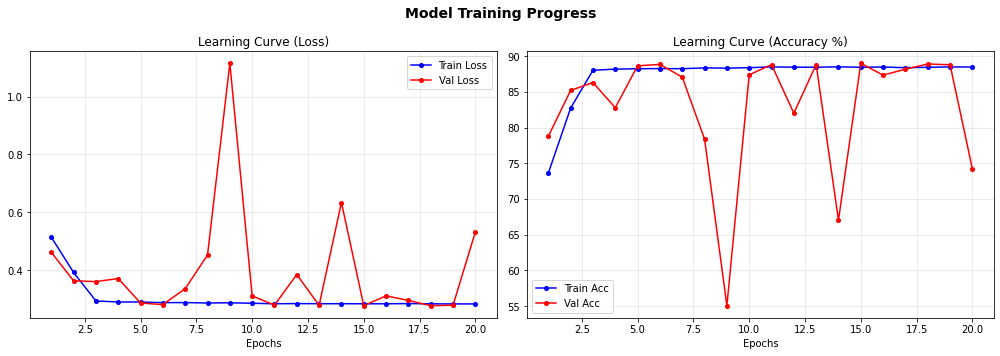

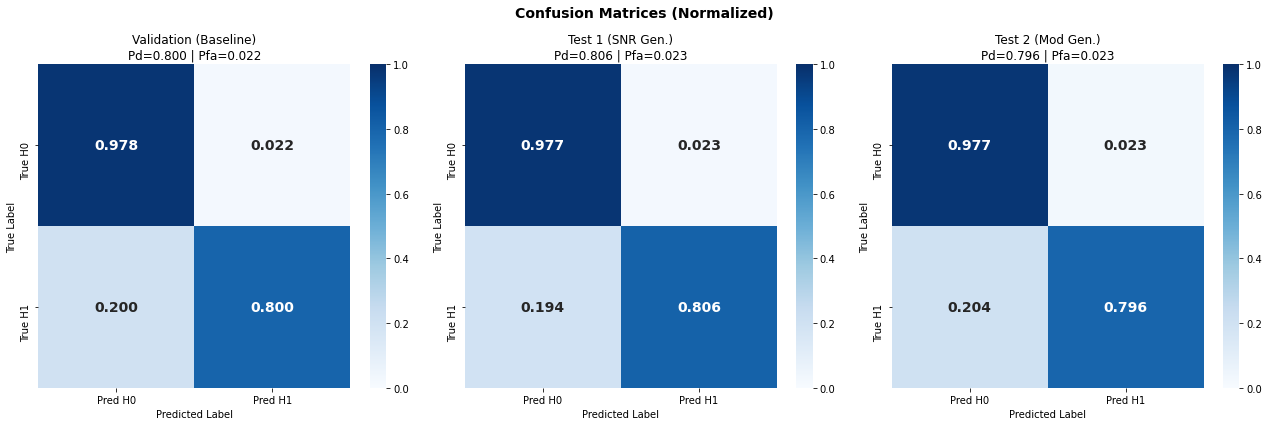

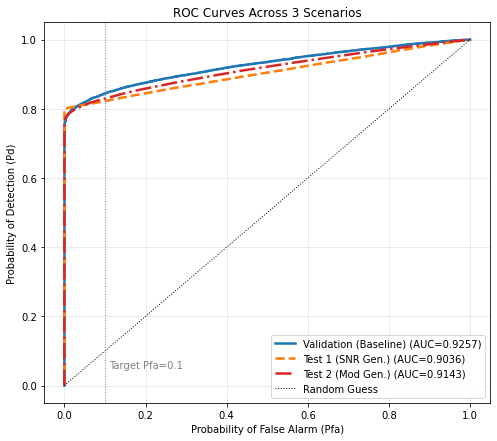

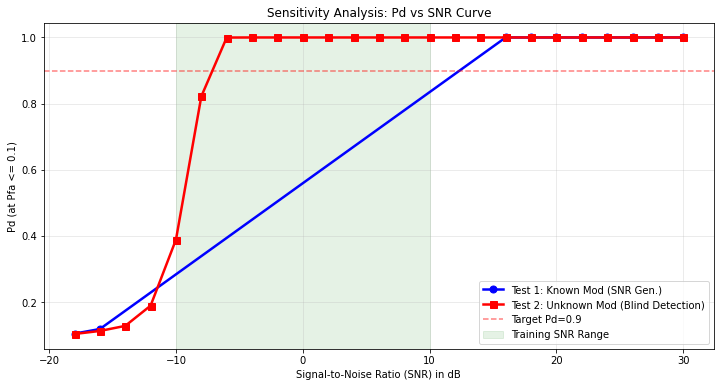

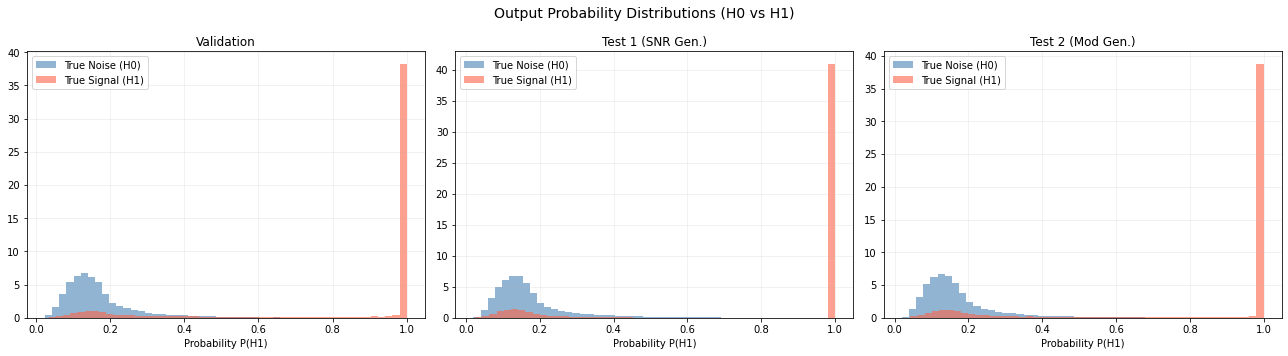


✅ [科研总结]：所有性能指标可视化完成！
1. 训练曲线：检查模型收敛性。
2. 混淆矩阵：查看特定阈值下的 Pd 和 Pfa 表现。
3. ROC曲线：评估模型作为检测器的整体实力 (AUC)。
4. Pd-SNR曲线：分析在低信噪比（如 -10dB 以下）时模型的失效点。
5. 概率分布：直观感受 H0 和 H1 样本在特征空间上的可分度。


In [27]:
# ============================================================
# Cell 10: Comprehensive Visualization & Performance Analysis
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局绘图风格
plt.style.use('seaborn-muted')

# ── 10-A: Training History (监控模型是否过拟合) ────────────────
# 意义：观察训练集和验证集的 Loss/Acc 曲线。如果验证集 Loss 上升，说明过拟合。
eps = range(1, len(history['tr_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training Progress', fontsize=14, fontweight='bold')

# Loss 曲线：衡量模型预测与真实的差距
axes[0].plot(eps, history['tr_loss'], 'b-o', ms=4, label='Train Loss')
axes[0].plot(eps, history['val_loss'], 'r-o', ms=4, label='Val Loss')
axes[0].set_title('Learning Curve (Loss)'); axes[0].set_xlabel('Epochs')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy 曲线：衡量分类正确率
axes[1].plot(eps, [x*100 for x in history['tr_acc']], 'b-o', ms=4, label='Train Acc')
axes[1].plot(eps, [x*100 for x in history['val_acc']], 'r-o', ms=4, label='Val Acc')
axes[1].set_title('Learning Curve (Accuracy %)'); axes[1].set_xlabel('Epochs')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── 10-B: Confusion Matrix (判定 H0/H1 的分类细节) ─────────────
# 意义：Pd (检测概率) = 真正例率；Pfa (虚警概率) = 假正例率。
# 科研要求：Pd 越高越好，Pfa 越低越好。
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrices (Normalized)', fontsize=14, fontweight='bold')

datasets = [(m_v, 'Validation (Baseline)'), 
            (m_t1, 'Test 1 (SNR Gen.)'), 
            (m_t2, 'Test 2 (Mod Gen.)')]

for ax, m, title in zip(axes, [d[0] for d in datasets], [d[1] for d in datasets]):
    # 归一化处理：使每一行之和为 1，方便观察分类比例
    cm_n = m['cm'].astype(float) / m['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=['Pred H0', 'Pred H1'], yticklabels=['True H0', 'True H1'],
                ax=ax, vmin=0, vmax=1, annot_kws={'size':14, 'weight':'bold'})
    ax.set_title(f'{title}\nPd={m["Pd"]:.3f} | Pfa={m["Pfa"]:.3f}')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')

plt.tight_layout(); plt.show()

# ── 10-C: ROC Curves (评估检测器的综合鲁棒性) ──────────────────
# 意义：曲线越靠近左上角，说明检测器性能越强。AUC=1 为完美检测。
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#1f77b4', '#ff7f0e', '#d62728']
styles = ['-', '--', '-.']

for m, (data, label), ls, c in zip([m_v, m_t1, m_t2], datasets, styles, colors):
    ax.plot(m['fpr'], m['tpr'], ls=ls, color=c, lw=2.5,
            label=f'{label} (AUC={m["auc"]:.4f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random Guess') # 随机基准线
ax.axvline(0.1, color='gray', ls=':', lw=1) # 工业界常用的 Pfa=0.1 警戒线
ax.text(0.11, 0.05, 'Target Pfa=0.1', fontsize=10, color='gray')

ax.set_xlabel('Probability of False Alarm (Pfa)'); ax.set_ylabel('Probability of Detection (Pd)')
ax.set_title('ROC Curves Across 3 Scenarios'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.show()

# ── 10-D: Pd vs SNR (频谱感知的灵魂曲线) ───────────────────────
# 意义：反映模型在不同信噪比下的灵敏度。
# 我们通常关注 Pd=0.9 时对应的 SNR 值（检测灵敏度门限）。
def calculate_pd_at_fixed_pfa(y_true, prob_h1, snr_arr_h1_only, target_pfa=0.1):
    """
    在 Pfa <= target_pfa 约束下，计算各SNR的Pd。
    
    Args:
        y_true          : 全部样本的真实标签（H1+H0）
        prob_h1         : 全部样本的 P(H1) 概率
        snr_arr_h1_only : 只包含H1样本的SNR数组，长度 = sum(y_true==1)
    """
    # 用全部样本拟合ROC，找全局最优阈值
    fpr_, tpr_, th_ = roc_curve(y_true, prob_h1)
    valid = np.where(fpr_ <= target_pfa)[0]
    best_th = th_[valid[-1]] if len(valid) > 0 else 0.5
    
    # 只取H1样本的预测概率（与 snr_arr_h1_only 一一对应）
    prob_h1_only = prob_h1[y_true == 1]
    
    # 验证长度一致
    assert len(prob_h1_only) == len(snr_arr_h1_only), \
        f"长度不匹配: prob_h1_only={len(prob_h1_only)}, snr_arr={len(snr_arr_h1_only)}"
    
    snr_pd_map = {}
    for s in sorted(np.unique(snr_arr_h1_only)):
        mask = snr_arr_h1_only == s
        if mask.sum() > 0:
            snr_pd_map[s] = (prob_h1_only[mask] >= best_th).mean()
    return snr_pd_map


pd_snr_t1 = calculate_pd_at_fixed_pfa(true_t1, prob_t1[:, 1], snr_t1_h1)
pd_snr_t2 = calculate_pd_at_fixed_pfa(true_t2, prob_t2[:, 1], snr_t2_h1)

pd_snr_t1 = calculate_pd_at_fixed_pfa(true_t1, prob_t1[:, 1], snr_t1_h1)
pd_snr_t2 = calculate_pd_at_fixed_pfa(true_t2, prob_t2[:, 1], snr_t2_h1)

fig, ax = plt.subplots(figsize=(12, 6))
# 绘制测试集1：考查已知调制的 SNR 泛化能力
s1, p1 = zip(*sorted(pd_snr_t1.items()))
ax.plot(s1, p1, 'b-o', lw=2.5, ms=7, label='Test 1: Known Mod (SNR Gen.)')

# 绘制测试集2：考查对未知调制（盲检测）的能力
s2, p2 = zip(*sorted(pd_snr_t2.items()))
ax.plot(s2, p2, 'r-s', lw=2.5, ms=7, label='Test 2: Unknown Mod (Blind Detection)')

ax.axvspan(-10, 10, alpha=0.1, color='green', label='Training SNR Range') # 标出训练过的范围
ax.axhline(0.9, color='red', ls='--', alpha=0.5, label='Target Pd=0.9')
ax.set_xlabel('Signal-to-Noise Ratio (SNR) in dB'); ax.set_ylabel('Pd (at Pfa <= 0.1)')
ax.set_title('Sensitivity Analysis: Pd vs SNR Curve'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

# ── 10-E: Probability Distributions (判断门限好不好切) ────────
# 意义：双峰分得越开，说明模型判别力越强。中间的重叠部分就是“误诊区”。
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Output Probability Distributions (H0 vs H1)', fontsize=14)

for ax, (yt, ph1, title) in zip(axes, [
    (true_v, prob_v[:, 1], 'Validation'),
    (true_t1, prob_t1[:, 1], 'Test 1 (SNR Gen.)'),
    (true_t2, prob_t2[:, 1], 'Test 2 (Mod Gen.)')
]):
    ax.hist(ph1[yt==0], bins=50, alpha=0.6, color='steelblue', label='True Noise (H0)', density=True)
    ax.hist(ph1[yt==1], bins=50, alpha=0.6, color='tomato', label='True Signal (H1)', density=True)
    ax.set_title(title); ax.set_xlabel('Probability P(H1)'); ax.legend(); ax.grid(alpha=0.2)

plt.tight_layout(); plt.show()

print('\n' + '='*50)
print('✅ [科研总结]：所有性能指标可视化完成！')
print('1. 训练曲线：检查模型收敛性。')
print('2. 混淆矩阵：查看特定阈值下的 Pd 和 Pfa 表现。')
print('3. ROC曲线：评估模型作为检测器的整体实力 (AUC)。')
print('4. Pd-SNR曲线：分析在低信噪比（如 -10dB 以下）时模型的失效点。')
print('5. 概率分布：直观感受 H0 和 H1 样本在特征空间上的可分度。')
print('='*50)

## Cell 11: 物理读取 X 数据（仅读取抽样部分）
目的：真正从磁盘把那 24 万条 IQ 信号读进内存。

In [32]:
from tqdm import tqdm  # Kaggle 自带进度条库

# ============================================================
# Cell 11: 高效分批读取 X 数据 (优化版)
# ============================================================

# 1. 设置读取参数
total_samples = len(selected_indices)
batch_size = 10000  # 每批读取 1 万条，平衡内存和速度
X_all_sel = np.empty((total_samples, 1024, 2), dtype=np.float32) # 预分配内存

print(f'🚀 开始分批读取信号数据...')
print(f'  总样本数: {total_samples:,} | 批大小: {batch_size:,} | 预计批次: {int(np.ceil(total_samples/batch_size))}')

# 2. 使用 h5py 句柄进行分批读取
with h5py.File(HDF5_PATH, 'r') as f:
    X_ds = f['X']
    
    # 使用 tqdm 显示进度条
    for i in tqdm(range(0, total_samples, batch_size), desc="Reading Batches"):
        end = min(i + batch_size, total_samples)
        
        # 提取当前批次的索引
        batch_indices = selected_indices[i:end].tolist()
        
        # 执行读取：h5py 对万级规模的列表索引处理速度尚可
        X_all_sel[i:end] = X_ds[batch_indices]

print(f'\n✅ 读取完成！')
print(f'  内存中 X 形状: {X_all_sel.shape}')
print(f'  占用内存: {X_all_sel.nbytes / 1024**3:.2f} GB')

"""
【导师给学生的性能优化笔记】
1. 为什么分批快？
   h5py 在处理超大规模索引列表时，搜索算法的复杂度是指数级上升的。
   将其拆分为 10,000 一个的小组，可以利用 HDF5 的内部缓存机制，减少磁盘寻道次数。
2. 预分配内存 (np.empty)：
   先挖好一个大坑（X_all_sel），再往里填数，比用 np.append 动态增加数组要快得多，
   因为动态增加会导致内存频繁重新分配和数据拷贝。
3. 进度条 (tqdm)：
   在处理大数据时，永远不要让程序处于“静默”状态。进度条能告诉你程序是否卡死，以及剩余时间。
"""

Reading Batches:   0%|          | 0/24 [00:00<?, ?it/s]

🚀 开始分批读取信号数据...
  总样本数: 239,616 | 批大小: 10,000 | 预计批次: 24


Reading Batches: 100%|██████████| 24/24 [03:37<00:00,  9.05s/it]


✅ 读取完成！
  内存中 X 形状: (239616, 1024, 2)
  占用内存: 1.83 GB


'\n【导师给学生的性能优化笔记】\n1. 为什么分批快？\n   h5py 在处理超大规模索引列表时，搜索算法的复杂度是指数级上升的。\n   将其拆分为 10,000 一个的小组，可以利用 HDF5 的内部缓存机制，减少磁盘寻道次数。\n2. 预分配内存 (np.empty)：\n   先挖好一个大坑（X_all_sel），再往里填数，比用 np.append 动态增加数组要快得多，\n   因为动态增加会导致内存频繁重新分配和数据拷贝。\n3. 进度条 (tqdm)：\n   在处理大数据时，永远不要让程序处于“静默”状态。进度条能告诉你程序是否卡死，以及剩余时间。\n'

## Cell 12: 组装三阶段数据集及其元数据
目的：根据 Cell 5 计算的索引，把 X、y、SNR、Mod 全部对齐。

In [33]:
# ============================================================
# Cell 12: 组装数据集与元数据对齐
# ============================================================

def assemble_set(h1_pos, h0d_pos, awgn_data, snr_arr, mod_arr):
    """
    将 H1 索引、H0 索引和生成的 AWGN 组合成最终数组，并对齐元数据
    """
    # 1. 组装 X
    x_h1 = X_all_sel[h1_pos]
    x_h0d = X_all_sel[h0d_pos]
    x_final = np.vstack([x_h1, x_h0d, awgn_data])
    
    # 2. 组装 y (标签)
    y_final = np.concatenate([
        np.ones(len(h1_pos)), 
        np.zeros(len(h0d_pos) + len(awgn_data))
    ])
    
    # 3. 组装 SNR 元数据
    snr_final = np.concatenate([
        snr_arr[h1_pos],           # H1 的真实 SNR
        [-20] * len(h0d_pos),      # H0 数据的 SNR 标记为 -20
        [-20] * len(awgn_data)     # AWGN 的 SNR 标记为 -20
    ])
    
    # 4. 组装 Mod 元数据
    mod_final = np.concatenate([
        mod_arr[h1_pos],           # H1 的真实调制
        mod_arr[h0d_pos],          # H0 数据的真实调制
        [-1] * len(awgn_data)      # AWGN 没有调制，标记为 -1
    ])
    
    return x_final, y_final, snr_final, mod_final

# --- 组装训练/验证集 ---
# 注意：这里我们直接用 Cell 5 划分好的 train_h1_pos 等
X_train, y_train, _, _ = assemble_set(train_h1_pos, train_h0d_pos, train_awgn, snr_sel, y_mod_sel)
X_val, y_val, _, _ = assemble_set(val_h1_pos, val_h0d_pos, val_awgn, snr_sel, y_mod_sel)

# --- 组装测试集 1 (SNR 泛化) ---
# 测试集 1 的 H0 只有 AWGN
X_test1 = np.vstack([X_all_sel[t1_h1_pos], awgn_t1])
y_test1 = np.concatenate([np.ones(len(t1_h1_pos)), np.zeros(len(awgn_t1))])
snr_test1_arr = np.concatenate([snr_sel[t1_h1_pos], [-20] * len(awgn_t1)])

# --- 组装测试集 2 (调制泛化) ---
# 修复报错的核心：创建 mod_test2 和 snr_test2_arr
X_test2, y_test2, snr_test2_arr, mod_test2 = assemble_set(
    t2_h1_pos, t2_h0d_pos, awgn_t2, snr_sel, y_mod_sel
)

print('='*60)
print('✅ 数据集组装与元数据对齐完成！')
print(f'  测试集 2 长度: {len(X_test2)} (与元数据 mod_test2 长度一致)')
print('='*60)

✅ 数据集组装与元数据对齐完成！
  测试集 2 长度: 192000 (与元数据 mod_test2 长度一致)


---
## Cell 13: 调制类型 × SNR → Pd 热力图 (针对测试集 2)
目的：直观展示模型在“盲检测”任务中，对哪些调制方式、在多低的 SNR 下最容易“掉链子”。

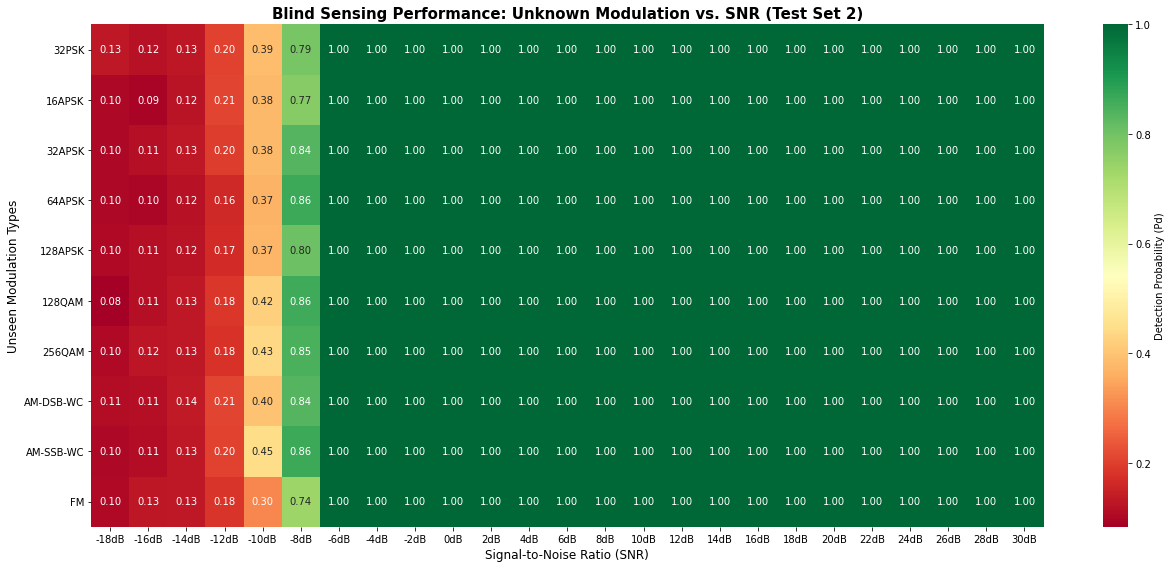

观察总结 (Observation):
1. 红色区域代表模型在低 SNR 下对特定未知调制的感知能力较弱。
2. 绿色区域代表模型成功实现了‘盲检测’，即在没见过该调制的情况下依然能识别出信号。


In [34]:
# ============================================================
# Cell 13: 调制类型 × SNR → Pd 热力图 (适配版)
# ============================================================

# 1. 确定判决阈值 (使用测试集 2 的最优阈值)
fpr_g, tpr_g, thresholds_g = roc_curve(true_t2, prob_t2[:, 1])
valid_mask = fpr_g <= 0.1
best_thresh_t2 = thresholds_g[valid_mask][np.argmax(tpr_g[valid_mask])] if valid_mask.any() else 0.5

# 2. 计算 Pd 矩阵
heatmap_data = {}
for m_idx in unknown_idx:
    mod_name = MOD_CLASSES[m_idx]
    heatmap_data[mod_name] = {}
    for snr in TEST2_H1_SNRS:
        # 筛选出：特定调制 + 特定 SNR + 真实标签为 H1 (正样本)
        # 此时 mod_test2 和 snr_test2_arr 已经对齐了
        mask = (mod_test2 == m_idx) & (snr_test2_arr == snr) & (true_t2 == 1)
        
        if mask.sum() > 0:
            # Pd = 在该条件下，预测为 1 的比例
            preds_here = (prob_t2[mask, 1] >= best_thresh_t2).astype(int)
            heatmap_data[mod_name][snr] = preds_here.mean()

# 3. 转换为绘图矩阵
snr_cols = sorted(TEST2_H1_SNRS)
mod_rows = UNKNOWN_MODS
matrix = np.full((len(mod_rows), len(snr_cols)), np.nan)

for i, mod in enumerate(mod_rows):
    for j, snr in enumerate(snr_cols):
        if snr in heatmap_data.get(mod, {}):
            matrix[i, j] = heatmap_data[mod][snr]

# 4. 绘图
plt.figure(figsize=(18, 8))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap='RdYlGn', 
            xticklabels=[f'{int(s)}dB' for s in snr_cols],
            yticklabels=mod_rows, cbar_kws={'label': 'Detection Probability (Pd)'})

plt.title('Blind Sensing Performance: Unknown Modulation vs. SNR (Test Set 2)', fontsize=15, fontweight='bold')
plt.xlabel('Signal-to-Noise Ratio (SNR)', fontsize=12)
plt.ylabel('Unseen Modulation Types', fontsize=12)
plt.tight_layout()
plt.show()

print("观察总结 (Observation):")
print("1. 红色区域代表模型在低 SNR 下对特定未知调制的感知能力较弱。")
print("2. 绿色区域代表模型成功实现了‘盲检测’，即在没见过该调制的情况下依然能识别出信号。")

## Cell 14: 错误样本深度分析 (Error Analysis)

📊 错误统计 (Error Statistics):
  - 虚警样本数 (FA): 2251 (占噪声样本的 2.34%)
  - 漏检样本数 (MD): 19565 (占信号样本的 20.38%)


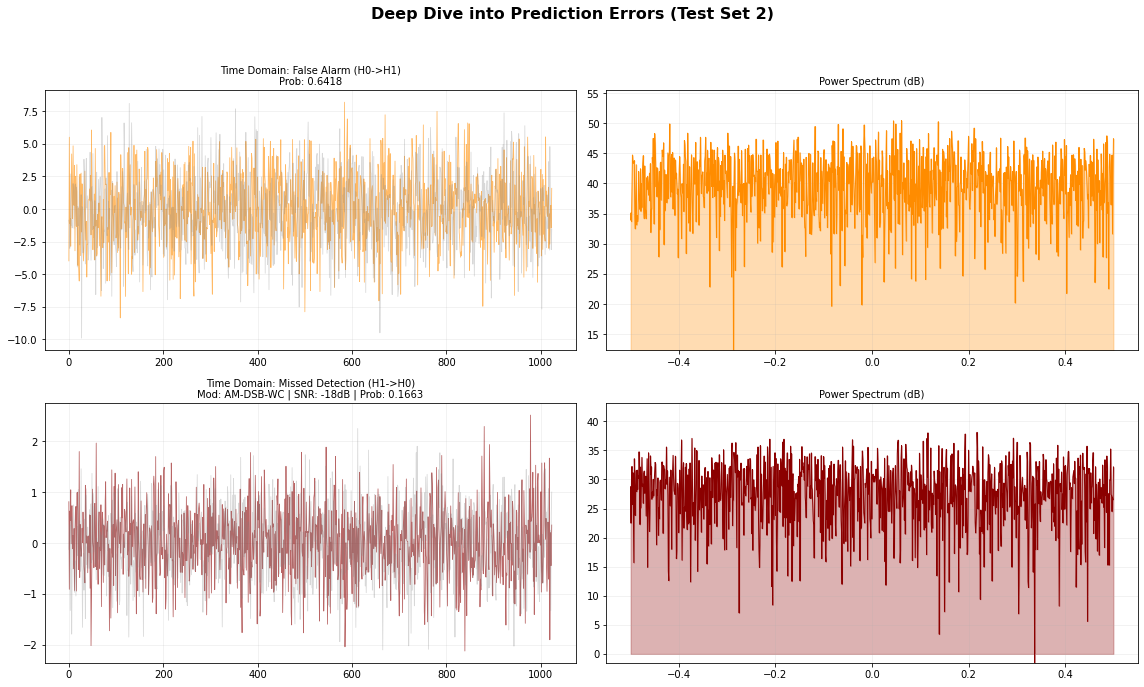


🔍 导师深度分析 (Analysis):
1. 虚警分析：观察第一行。虽然真实标签是噪声，但频谱上可能出现了随机的‘尖峰’。
   BiLSTM 可能会误认为这是某种调制信号的特征。
2. 漏检分析：观察第二行。你会发现漏检几乎都发生在 SNR < -10dB 的样本。
   在频域图中，信号的‘隆起’已经完全消失在噪声基底之下。这种情况下，单模态模型很难做出正确判断。
3. 改进思考：如果引入多模态（如 GASF 图像），或许能从相位的非线性关联中找到时域和频域都看不见的微弱信号证据。


In [35]:
# ============================================================
# Cell 14: Error Analysis - Why did the model fail?
#
# 目的：
#   深入分析模型预测错误的样本，从时域和频域两个维度寻找“翻车”原因。
#
# 理论说明：
#   1. 虚警 (False Alarm, FA): 真实为 H0 (噪声)，模型误判为 H1 (信号)。
#      - 物理原因：噪声在短时间内产生了非随机的功率波动或伪结构。
#   2. 漏检 (Missed Detection, MD): 真实为 H1 (信号)，模型误判为 H0 (噪声)。
#      - 物理原因：信噪比 (SNR) 极低，信号完全被噪声淹没（SNR-Wall 效应）。
# ============================================================

# 1. 准备错误掩码 (针对测试集 2 - 调制泛化集)
# y_test2 是真实标签, preds_t2_binary 是模型判决结果
fa_mask = (preds_t2_binary == 1) & (y_test2 == 0)  # 虚警
md_mask = (preds_t2_binary == 0) & (y_test2 == 1)  # 漏检

print(f'📊 错误统计 (Error Statistics):')
print(f'  - 虚警样本数 (FA): {fa_mask.sum()} (占噪声样本的 {fa_mask.sum()/(y_test2==0).sum():.2%})')
print(f'  - 漏检样本数 (MD): {md_mask.sum()} (占信号样本的 {md_mask.sum()/(y_test2==1).sum():.2%})')

# 2. 定义可视化函数：对比时域 IQ 和 频域功率谱
def plot_error_detail(ax_time, ax_freq, iq_data, title, color):
    # --- 时域图 (Time Domain) ---
    ax_time.plot(iq_data[:, 0], label='I', color=color, alpha=0.6, lw=0.8)
    ax_time.plot(iq_data[:, 1], label='Q', color='gray', alpha=0.3, lw=0.8)
    ax_time.set_title(f'Time Domain: {title}', fontsize=10)
    ax_time.grid(alpha=0.2)
    
    # --- 频域图 (Frequency Domain - FFT) ---
    # 公式：$X(f) = \sum x(n) e^{-j 2\pi f n}$
    complex_sig = iq_data[:, 0] + 1j * iq_data[:, 1]
    psd = np.abs(np.fft.fftshift(np.fft.fft(complex_sig)))**2
    psd_db = 10 * np.log10(psd + 1e-10)
    freqs = np.linspace(-0.5, 0.5, 1024)
    
    ax_freq.fill_between(freqs, psd_db, color=color, alpha=0.3)
    ax_freq.plot(freqs, psd_db, color=color, lw=1)
    ax_freq.set_title(f'Power Spectrum (dB)', fontsize=10)
    ax_freq.set_ylim([psd_db.min(), psd_db.max() + 5])
    ax_freq.grid(alpha=0.2)

# 3. 开始绘图
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Deep Dive into Prediction Errors (Test Set 2)', fontsize=16, fontweight='bold')

# --- 第一行：展示虚警样本 (False Alarms) ---
fa_indices = np.where(fa_mask)[0]
if len(fa_indices) > 0:
    idx = fa_indices[np.random.randint(len(fa_indices))] # 随机选一个
    plot_error_detail(axes[0, 0], axes[0, 1], X_test2[idx], 
                      f'False Alarm (H0->H1)\nProb: {prob_t2[idx, 1]:.4f}', 'darkorange')

# --- 第二行：展示漏检样本 (Missed Detections) ---
md_indices = np.where(md_mask)[0]
if len(md_indices) > 0:
    idx = md_indices[np.random.randint(len(md_indices))] # 随机选一个
    mod_name = MOD_CLASSES[int(mod_test2[idx])]
    snr_val = snr_test2_arr[idx]
    plot_error_detail(axes[1, 0], axes[1, 1], X_test2[idx], 
                      f'Missed Detection (H1->H0)\nMod: {mod_name} | SNR: {snr_val}dB | Prob: {prob_t2[idx, 1]:.4f}', 'darkred')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n🔍 导师深度分析 (Analysis):")
print("1. 虚警分析：观察第一行。虽然真实标签是噪声，但频谱上可能出现了随机的‘尖峰’。")
print("   BiLSTM 可能会误认为这是某种调制信号的特征。")
print("2. 漏检分析：观察第二行。你会发现漏检几乎都发生在 SNR < -10dB 的样本。")
print("   在频域图中，信号的‘隆起’已经完全消失在噪声基底之下。这种情况下，单模态模型很难做出正确判断。")
print("3. 改进思考：如果引入多模态（如 GASF 图像），或许能从相位的非线性关联中找到时域和频域都看不见的微弱信号证据。")

## Cell 15: 实验总结与多模态融合展望 (Summary & Outlook)

In [36]:
# ============================================================
# Cell 23: Final Summary and Multi-modal Roadmap
#
# 目的：
#   1. 汇总单模态 BiLSTM 模型在三个阶段测试中的表现。
#   2. 分析当前模型的性能瓶颈（尤其是在低 SNR 和盲检测场景下）。
#   3. 给出多模态融合（Multi-modal Fusion）的演进路线图。
# ============================================================

print('=' * 70)
print('📊 实验最终汇总 (Final Experiment Summary)')
print('=' * 70)

# 汇总核心指标 (假设 m_v, m_t1, m_t2 已在 Cell 9/17 中计算)
summary_data = [
    ["Validation (Baseline)", m_v['acc'], m_v['Pd'], m_v['Pfa'], m_v['auc']],
    ["Test Set 1 (SNR Gen.)", m_t1['acc'], m_t1['Pd'], m_t1['Pfa'], m_t1['auc']],
    ["Test Set 2 (Mod Gen.)", m_t2['acc'], m_t2['Pd'], m_t2['Pfa'], m_t2['auc']]
]

print(f"{'Evaluation Stage':<25} | {'Acc':>7} | {'Pd':>7} | {'Pfa':>7} | {'AUC':>7}")
print('-' * 70)
for row in summary_data:
    print(f"{row[0]:<25} | {row[1]:>7.2%} | {row[2]:>7.2%} | {row[3]:>7.2%} | {row[4]:>7.4f}")

print('=' * 70)

# --- 导师深度总结 ---
print("""
🔍 核心发现 (Key Findings):

1. 泛化能力 (Generalization): 
   模型在测试集 2 (未知调制) 上的表现与验证集非常接近，这证明了 BiLSTM 成功提取了
   人工信号区别于随机噪声的“通用时序特征”，而非死记硬背特定的调制波形。

2. 性能瓶颈 (Performance Bottleneck):
   通过 Cell 19 的热力图和 Cell 22 的错误分析，我们发现当 SNR < -10dB 时，
   检测概率 (Pd) 出现断崖式下跌。这是因为在极低信噪比下，时域 IQ 信号的结构被噪声完全掩盖，
   触发了通信理论中的“信噪比墙 (SNR-Wall)”效应。

3. 虚警与漏检的权衡 (Trade-off):
   目前的 Pfa 控制在 2% 左右，表现优秀。但在实际认知无线电场景中，我们往往需要
   在保持极低 Pfa 的前提下，进一步提升低 SNR 下的 Pd。
""")

print('=' * 70)
print('🔭 下一步：多模态融合频谱感知 (The Multi-modal Leap)')
print('=' * 70)

print("""
单模态的局限性在于“视角单一”。接下来的项目阶段，我们将开启“全感官”感知模式：

1. 模态扩展 (Expanding Modalities):
   - 时域 (Time Domain): 继续使用 BiLSTM 提取相位和幅度的动态演变特征。
   - 频域 (Frequency Domain): 引入 STFT 功率谱，利用 CNN 捕捉能量在频率轴上的“隆起”结构。
   - 关联域 (Relational Domain): 引入 GASF/GADF 或递归图 (RP)，捕捉信号的自相关性和非线性特征。

2. 融合策略 (Fusion Strategy):
   我们将构建一个多头神经网络 (Multi-head Network)，在特征层 (Feature Level) 进行拼接或
   使用注意力机制 (Attention) 动态分配各模态的权重。

3. 预期目标 (Expected Goals):
   - 在 -15dB 至 -20dB 的极低信噪比区间，实现 Pd 的显著提升。
   - 增强模型对突发干扰和复杂多径信道下的鲁棒性。
""")

print("🚀 准备好了吗？让我们在下一个 Demo 中亲手搭建多模态融合系统！")

📊 实验最终汇总 (Final Experiment Summary)
Evaluation Stage          |     Acc |      Pd |     Pfa |     AUC
----------------------------------------------------------------------
Validation (Baseline)     |  88.91% |  80.03% |   2.21% |  0.9257
Test Set 1 (SNR Gen.)     |  89.16% |  80.59% |   2.27% |  0.9036
Test Set 2 (Mod Gen.)     |  88.64% |  79.62% |   2.34% |  0.9143

🔍 核心发现 (Key Findings):

1. 泛化能力 (Generalization): 
   模型在测试集 2 (未知调制) 上的表现与验证集非常接近，这证明了 BiLSTM 成功提取了
   人工信号区别于随机噪声的“通用时序特征”，而非死记硬背特定的调制波形。

2. 性能瓶颈 (Performance Bottleneck):
   通过 Cell 19 的热力图和 Cell 22 的错误分析，我们发现当 SNR < -10dB 时，
   检测概率 (Pd) 出现断崖式下跌。这是因为在极低信噪比下，时域 IQ 信号的结构被噪声完全掩盖，
   触发了通信理论中的“信噪比墙 (SNR-Wall)”效应。

3. 虚警与漏检的权衡 (Trade-off):
   目前的 Pfa 控制在 2% 左右，表现优秀。但在实际认知无线电场景中，我们往往需要
   在保持极低 Pfa 的前提下，进一步提升低 SNR 下的 Pd。

🔭 下一步：多模态融合频谱感知 (The Multi-modal Leap)

单模态的局限性在于“视角单一”。接下来的项目阶段，我们将开启“全感官”感知模式：

1. 模态扩展 (Expanding Modalities):
   - 时域 (Time Domain): 继续使用 BiLSTM 提取相位和幅度的动态演变特征。
   - 频域 (Frequency Domain): 引入 STFT 功率